In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck15
import astropy.constants as const
import astropy.units as u
from astropy.table import Table
from astropy.io import fits
from scipy.integrate import quad
from scipy import interpolate
u_parser = u.format.Fits()

        Use FITS instead. [astropy.units.format]


In [2]:
h=0.69
cosmo = Planck15.clone(H0=h*100)

# IA Estimation

This notebook estimates the IA amplitude of several different galaxy samples for direct IA measurement forecast. The goal is to use the A(L,z) relation measured from other literature, and apply it to a hypothetic galaxy sample selected from some deep field catalog or mock catalog.

## Surveys Considered

- Roman HLWAS
    - Roman Deep Tier: 
        - 19.2 deg2 $WZ_{F087}Y_{F106}J_{F129}H_{F158}FK$ 7 bands + Grism
        - Deeps are $m_{Z087}=m_{Y106}=27.7$, $m_{J129}=27.6$, $m_{H158}=27.5$, $m_F=27.0$, $m_K=25.9$, $m_W=28.3$, Grism = 5.8e-17 cgs
    - Roman Medium Tier:
        - 2415 deg2 in $YJH$ + Grism
        - $m_Y=26.5$, $m_J=26.4$, $m_H=26.4$, Grism = 1.5e-16 cgs
    - Roman Wide Tier:
        - 2702 deg2 in $H$ band, $m_H=26.2$
- DESC: Ask Zepei and Jamie
- DESI-II: Ask Zepei and Jamie

In [3]:
### Roman Instrument
ROMAN_EFF50PSF = 0.11 # arcsec
ROMAN_GRISM_WAVE_MIN = 1.00*u.um
ROMAN_GRISM_WAVE_MAX = 1.93*u.um

### Roman Deep Tier
ROMAN_DEEP_JH_DEPTH = 27.5
ROMAN_DEEP_GRISM_DEPTH = 5.8e-17 * (u.erg / u.s / u.cm**2)

### Roman Medium Tier
ROMAN_MEDIUM_JH_DEPTH = 26.4
ROMAN_MEDIUM_GRISM_DEPTH = 1.5e-16 * (u.erg / u.s / u.cm**2)

### Roman Wide Tier
ROMAN_WIDE_JH_DEPTH = 26.2

## Samples considered

- Samples with spectroscopic redshift
    - **Roman Deep Sample**: spectroscopic redshift from grism, and shape measurement from the deep tier Roman imaging
        - Emission line flux > 5.8e-17 cgs
        - Photometric image bright enough: J+H band SNR > 18
        - Spatial resolution factor $R > 0.4$
        - Shape measurement rms error $\sigma(\epsilon)<0.2$
    - **Roman Medium Sample** (aka KL sample): spectroscopic redshift from grism, and shape measurement from medium tier Roman imaging
        - Emission line flux > 1.5e-16 cgs
        - J+H band SNR > 18
        - Spatial resolution factor $R>0.4$
        - Shape measurement rms error $\sigma(\epsilon)<0.2$
    - **DESC x DESI-II**: spectroscopic redshift from DESI-II, and shape measurement from Rubin Observatory
        - I think Jaime has a catalog?
- Samples with photometric redshift
    - **Roman Wide/Wide+Medium Tier redMaGiC-like sample**: Accurate photo-z from redMaGiC template.
        - J+H band SNR > 18
        - Spatial resolution factor R>0.4
        - Shape measurement rms error $\sigma(\epsilon)<0.2$
        - Is redMaGiC galaxy...
For those galaxy samples, we also need to get their rest-frame r-band luminoisty.  

In [4]:
R_SPATIAL_THRESHOLD = 0.4
JH_SNR_THRESHOLD = 18
SHAPE_ERROR_THRESHOLD = 0.2

## Target Selection Catalog:

- CANDELS: too shallow, not used in this notebook
- COSMOS Mock Catalog: too shallow, not used in this notebook
- **COSMOS2025**: rought the same depth to Roman Deep Tier
    - $0.43\degree^2$ after masking in JWST/NIRCam, $0.54\degree^2$ (1920 arcmin2) in total footprint
    - Download link: https://cosmos2025.iap.fr/catalog_download.php
    - README description: https://cosmos2025.iap.fr/catalog.html
    - Paper: https://arxiv.org/abs/2506.03243

### Sample Selection

In [5]:
def get_SNR_image(catalog, band, depth):
    ''' Get the SNR of the image in a given band. 
    Parameters
    ----------
    catalog: astropy Table
        The catalog containing the magnitude information.
    band: str
        The band for which to calculate the SNR (e.g., 'f115w', 'f150w').
    depth: astropy Quantity
        The 5-sigma point-source depth of the image in the given band (in magnitude).
    Returns
    -------
    SNR: numpy array
        The signal-to-noise ratio of the image in the given band.
    '''
    mag = catalog[f'mag_model_{band}']
    SNR = 10**(-0.4*(mag - depth))
    return SNR
def get_spatial_resolution_factor(catalog, EEF50PSF=0.045):
    ''' Get the spatial resolution factor R for a given band.
    Parameters
    ----------
    catalog: astropy Table
        The catalog containing the half-light radius information.
    band: str
        The band for which to calculate the spatial resolution factor (e.g., 'f115w', 'f150w').
    EEF50PSF: float
        The 50% encircled energy radius of the PSF in arcseconds.
    Returns
    -------
    R: numpy array
        The spatial resolution factor for the given band.
    '''
    r_eff_gal = catalog[f'radius_sersic'] * 3600 # half-light radius in arcseconds
    R = (1 + (EEF50PSF / r_eff_gal)**2)**(-1)
    return R

def get_shape_measurement_error(catalog):
    ''' Get the rms shape measurement error, aka the per-component measurement error of galaxies 
    Parameters
    ----------
    catalog: astropy Table
        The catalog containing the half-light radius information.
    Returns
    -------
    sigma: numpy array
        The ellipticity measurement error
    '''
    return np.sqrt((catalog["e1_err"]**2 + catalog["e2_err"]**2)/2.)


In [6]:
def estimate_emission_line_fluxes(catalog_data_SED,
                                  catalog_data_photoz,
                                   apply_dust=True,
                                   dust_scale_factor=1.3,
                                   cosmology=None):
    """
    Estimate Ha, [OII], and [OIII] emission line fluxes from COSMOS-Web catalog
    
    Parameters:
    -----------
    catalog_data_SED : dict or astropy.table.Table
        COSMOS-Web catalog data containing CIGALE columns:
        Required columns:
        - sfr_inst: instantaneous SFR [M_sol/yr]
        - sfr_100myr: 100 Myr averaged SFR [M_sol/yr]
        - sfh_integrated: total stellar mass [M_sol]
        - sfh_sfr_bin1 through sfh_sfr_bin9: normalized SFR [1/yr]
        - sfh_time_bin1 through sfh_time_bin9: lookback times [Myr]
        - mass: stellar mass [M_sol]
        - metallicity: stellar metallicity (0.02 = solar)

    catalog_data_photoz : dict or astropy.table.Table
        COSMOS-Web catalog data containing LEPHARE columns:
        Required columns:
        - zfinal: photometric redshift
        - ebv_minchi2: E(B-V) from SED fit (optional, for dust correction)
    
    apply_dust : bool, default=True
        Apply dust attenuation correction
    
    dust_scale_factor : float, default=1.3
        Scale factor for nebular E(B-V) relative to stellar E(B-V)
        Typical range: 1.0-1.5
    
    cosmology : astropy.cosmology, optional
        Cosmology for distance calculations
        Default: FlatLambdaCDM(H0=70, Om0=0.3)
    
    Returns:
    --------
    results : dict
        Dictionary containing:
        - F_Ha: H浼?flux [erg/s/cm^2]
        - F_OII: [OII]娴?727 flux [erg/s/cm^2]
        - F_OIII: [OIII]娴?007 flux [erg/s/cm^2]
        - lambda_Ha_obs: observed H浼?wavelength [Angstrom]
        - lambda_OII_obs: observed [OII] wavelength [Angstrom]
        - lambda_OIII_obs: observed [OIII] wavelength [Angstrom]
        - redshift: photometric redshift
        - sfr_young: effective SFR for emission lines [M_sol/yr]
        - log_U: ionization parameter
    
    Notes:
    ------
    - Uses Kennicutt (1998) H浼?SFR calibration (Chabrier IMF)
    - Line ratios depend on metallicity and ionization parameter
    - Prioritizes young (< 10 Myr) SFH for ionizing photon budget
    """
    
    # Initialize cosmology
    if cosmology is None:
        cosmo = Planck15
    else:
        cosmo = cosmology
    
    # Physical constants
    Z_solar = 0.02
    lambda_Ha_rest = 6562.8   # Angstrom
    lambda_OII_rest = 3727.5  # Angstrom
    lambda_OIII_rest = 5006.8 # Angstrom
    
    # Dust extinction coefficients (Cardelli+89)
    k_Ha = 2.53
    k_OII = 3.60
    k_OIII = 2.98
    
    # Extract catalog columns
    n_gal = len(catalog_data_SED['sfr_inst'])
    
    sfr_inst = np.array(catalog_data_SED['sfr_inst'])
    sfr_100myr = np.array(catalog_data_SED['sfr_100myr'])
    sfh_integrated = np.array(catalog_data_SED['sfh_integrated'])
    stellar_mass = np.array(catalog_data_SED['mass'])
    metallicity = np.array(catalog_data_SED['metallicity'])
    redshift = np.array(catalog_data_photoz['zfinal'])
    
    # Extract SFH bins
    sfh_times = np.array([
        catalog_data_SED[f'sfh_time_bin{i}'] for i in range(1, 10)
    ]).T  # Shape: (n_gal, 9)
    
    sfh_sfrs_norm = np.array([
        catalog_data_SED[f'sfh_sfr_bin{i}'] for i in range(1, 10)
    ]).T  # Shape: (n_gal, 9)
    
    # =========================================================================
    # Step 1: Extract effective SFR from young stellar populations
    # =========================================================================
    
    # Convert normalized SFRs to absolute: SFR = sfh_sfr_norm * M_total
    sfh_sfrs_abs = sfh_sfrs_norm * sfh_integrated[:, np.newaxis]
    
    # Focus on young populations (< 10 Myr) that produce ionizing photons
    sfr_young = np.zeros(n_gal)
    
    for i in range(n_gal):
        times = sfh_times[i]
        sfrs = sfh_sfrs_abs[i]
        
        # Mask for young, valid populations
        young_mask = (times < 10.1) & (times > 0) & np.isfinite(times) & np.isfinite(sfrs)
        
        if np.any(young_mask):
            # Weight by 1/age (younger stars produce more ionizing photons)
            weights = 1.0 / (times[young_mask] + 0.5)
            weights /= np.sum(weights)
            sfr_young[i] = np.sum(sfrs[young_mask] * weights)
        else:
            sfr_young[i] = sfr_inst[i]
    
    # Fallback to 100 Myr SFR if needed
    bad_mask = ~np.isfinite(sfr_young) | (sfr_young <= 0)
    sfr_young[bad_mask] = sfr_100myr[bad_mask]
    
    # Last resort: use instantaneous SFR
    still_bad = ~np.isfinite(sfr_young) | (sfr_young <= 0)
    sfr_young[still_bad] = sfr_inst[still_bad]
    
    # =========================================================================
    # Step 2: Calculate ionization parameter
    # =========================================================================
    
    # log(U) depends on SFR surface density and metallicity
    # 閸楃浕SFR 闁?SFR / R_e^2, and R_e 闁?M^0.25
    # So log(閸楃浕SFR) 闁?log(SFR/M^0.5)
    
    log_sfr_sigma = np.log10(np.maximum(sfr_young, 1e-3)) - 0.5 * np.log10(np.maximum(stellar_mass, 1e8))
    Z_ratio = metallicity / Z_solar
    
    # Empirical relation calibrated to observations
    log_U = -2.5 + 0.3 * log_sfr_sigma - 0.6 * np.log10(np.maximum(Z_ratio, 0.1))
    log_U = np.clip(log_U, -4.0, -1.5)
    
    # =========================================================================
    # Step 3: Calculate emission line ratios
    # =========================================================================
    
    log_Z_ratio = np.log10(np.maximum(Z_ratio, 0.05))
    
    # [OII]/H娴? increases at lower Z
    log_OII_Ha = -0.40 + 0.35 * log_Z_ratio + 0.10 * (log_U + 2.5)
    log_OII_Ha = np.clip(log_OII_Ha, -0.8, 0.3)
    
    # [OIII]/H娴? increases at lower Z and higher ionization
    log_OIII_Ha = -0.50 - 0.40 * log_Z_ratio + 0.60 * (log_U + 2.5)
    log_OIII_Ha = np.clip(log_OIII_Ha, -1.2, 0.5)
    
    # =========================================================================
    # Step 4: Calculate H娴?luminosity from SFR
    # =========================================================================
    
    # Kennicutt (1998) calibration for Chabrier IMF
    # L(H娴? = 1.26 閼?10^41 閼?SFR [erg/s]
    L_Ha = 1.26e41 * sfr_young  # erg/s
    
    # Other line luminosities
    L_OII = L_Ha * 10**log_OII_Ha
    L_OIII = L_Ha * 10**log_OIII_Ha
    
    # =========================================================================
    # Step 5: Apply dust correction (optional)
    # =========================================================================
    
    if apply_dust:
        # Get E(B-V) from catalog, scale for nebular regions
        try:
            ebv_stellar = np.array(catalog_data_photoz['ebv_minchi2'])
        except KeyError:
            ebv_stellar = np.zeros(n_gal)
        ebv_nebular = ebv_stellar * dust_scale_factor
        
        # Calculate extinction in magnitudes
        A_Ha = k_Ha * ebv_nebular
        A_OII = k_OII * ebv_nebular
        A_OIII = k_OIII * ebv_nebular
        
        # Correct luminosities: L_intrinsic = L_observed * 10^(0.4 * A)
        L_Ha *= 10**(0.4 * A_Ha)
        L_OII *= 10**(0.4 * A_OII)
        L_OIII *= 10**(0.4 * A_OIII)
    
    # =========================================================================
    # Step 6: Convert luminosities to observed fluxes
    # =========================================================================
    
    # Calculate luminosity distances
    d_L = np.zeros(n_gal)
    valid_z = (redshift > 0) & np.isfinite(redshift)
    d_L[valid_z] = cosmo.luminosity_distance(redshift[valid_z]).to('cm').value
    
    # Observed flux: F = L / (4閿?d_L^2)
    F_Ha = np.zeros(n_gal)
    F_OII = np.zeros(n_gal)
    F_OIII = np.zeros(n_gal)
    
    valid_flux = valid_z & (d_L > 0)
    F_Ha[valid_flux] = L_Ha[valid_flux] / (4 * np.pi * d_L[valid_flux]**2)
    F_OII[valid_flux] = L_OII[valid_flux] / (4 * np.pi * d_L[valid_flux]**2)
    F_OIII[valid_flux] = L_OIII[valid_flux] / (4 * np.pi * d_L[valid_flux]**2)
    
    # =========================================================================
    # Step 7: Calculate observed wavelengths
    # =========================================================================
    
    lambda_Ha_obs = lambda_Ha_rest * (1 + redshift)
    lambda_OII_obs = lambda_OII_rest * (1 + redshift)
    lambda_OIII_obs = lambda_OIII_rest * (1 + redshift)
    
    # =========================================================================
    # Package results
    # =========================================================================
    
    results = {
        # Emission line fluxes [erg/s/cm^2]
        'F_Ha': F_Ha,
        'F_OII': F_OII,
        'F_OIII': F_OIII,
        
        # Observed wavelengths [Angstrom]
        'lambda_Ha_obs': lambda_Ha_obs,
        'lambda_OII_obs': lambda_OII_obs,
        'lambda_OIII_obs': lambda_OIII_obs,
        
        # Redshift
        'redshift': redshift,
        
        # Derived physical properties
        'sfr_young': sfr_young,
        'log_U': log_U,
    }
    
    return results

In [7]:
def realistic_roman_redmagic(catalog_data, 
                             assume_roman_photoz=True,
                             roman_photoz_error_floor=0.02,
                             z_min=0.2, z_max=1.5,
                             max_log_ssfr=-10.5, min_log_mass=10.3, l_min=0.5):
    """
    redMaGiC selection with realistic Roman+LSST photo-z quality
    
    Parameters:
    -----------
    assume_roman_photoz : bool
        If True, degrade COSMOS photo-z to Roman+LSST levels
        If False, use native COSMOS photo-z (optimistic)
    """
    
    z = np.array(catalog_data['zfinal'])
    M_r = np.array(catalog_data['mabs_r'])
    log_mass = np.array(catalog_data['mass_med'])
    log_ssfr = np.array(catalog_data['ssfr_med'])
    
    # Get COSMOS photo-z uncertainty
    z_l68 = catalog_data['zpdf_l68']
    z_u68 = catalog_data['zpdf_u68']
    sigma_z_cosmos = (z_u68 - z_l68) / 2.0
    
    # =====================================================
    # Degrade photo-z to Roman+LSST quality
    # =====================================================
    
    if assume_roman_photoz:
        # COSMOS: 閿滅禆z ~ 0.01 (34 bands)
        # Roman+LSST: 閿滅禆z ~ 0.025 (10 bands)
        # Degradation factor ~ 2.5
        
        sigma_z_roman = np.sqrt(
            sigma_z_cosmos**2 + 
            (roman_photoz_error_floor * (1 + z))**2  # Add Roman+LSST scatter in quadrature
        )
        
        # Increase outlier rate: 0.5% 闁?6%
        # Randomly flag 5.5% as catastrophic outliers
        np.random.seed(42)
        is_outlier = np.random.random(len(z)) < 0.055
        
        # Photo-z quality cut (remove likely outliers)
        # In real Roman: use chi閾? PDF shape, etc.
        # Here: use increased scatter as proxy
        good_photoz = (sigma_z_roman < 0.05) & ~is_outlier
        
    else:
        # Use native COSMOS photo-z (optimistic)
        good_photoz = sigma_z_cosmos < 0.03
    
    # =====================================================
    # Standard redMaGiC cuts
    # =====================================================
    
    # Core selection
    z_range = (z >= z_min) & (z <= z_max)
    
    # Luminosity threshold (volume-limited)
    M_star_z = -21.5 - z
    M_threshold = M_star_z - 2.5 * np.log10(l_min)  # L > 0.5 L*
    luminous = M_r < M_threshold
    
    # Red/quiescent
    quiescent = log_ssfr < max_log_ssfr
    massive = log_mass > min_log_mass
    
    # Valid data
    valid = (
        np.isfinite(M_r) & np.isfinite(z) & 
        np.isfinite(log_mass) & np.isfinite(log_ssfr) &
        (M_r > -30) & (M_r < -15)
    )
    
    # Combined selection
    redmagic_mask = (
        z_range &
        luminous &
        quiescent &
        massive &
        good_photoz &  # THIS is the Roman degradation
        valid
    )
    
    # =====================================================
    # Report impact of photo-z degradation
    # =====================================================
    
    # Without photo-z quality cut (optimistic)
    redmagic_nophotz = (
        z_range & luminous & quiescent & massive & valid
    )
    
    return redmagic_mask

In [8]:
### CMC catalog
### http://cdsarc.u-strasbg.fr/viz-bin/qcat?J/A+A/504/359
#CMC = '/Users/jiachuanxu/Workspace/CMC/CMC.fits'
#catalog_CMC = Table().read(CMC, format='fits')

### CANDELS catalog
# catalog_CANDELS = Table().read('/Users/jiachuanxu/Workspace/CANDELS/CANDELS.GOODSS.F160W.v1.fits', format='fits')
# for col in catalog_CANDELS.colnames:
#     print(col)

### COSMOS2025 catalog
### Download: https://cosmos2025.iap.fr/catalog_download.html
### README: https://cosmos2025.iap.fr/catalog.html
### Paper:https://arxiv.org/abs/2506.03243
### Please refer to https://cosmos2025.iap.fr/catalog.html#detailed-column-descriptions for detailed column descriptions.
catalog_c25 = Table().read('D:\\research\\fits_data\\COSMOSWeb_mastercatalog_v1.fits')
catalog_c25_phot = Table().read('D:\\research\\fits_data\\COSMOSWeb_mastercatalog_v1_photom_primary.fits')
catalog_c25_SED = Table().read('D:\\research\\fits_data\\COSMOSWeb_mastercatalog_v1_cigale.fits')
catalog_c25_photoz = Table().read('D:\\research\\fits_data\\COSMOSWeb_mastercatalog_v1_lephare.fits')
emission_line_results = estimate_emission_line_fluxes(catalog_c25_SED, catalog_c25_photoz, apply_dust=True, dust_scale_factor=1.3)

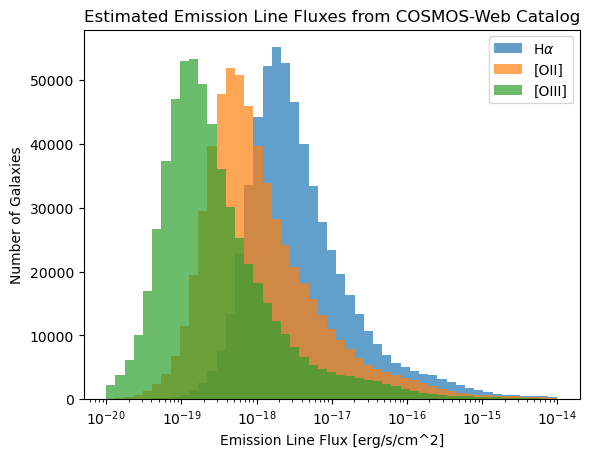

In [9]:
### First, let's look at the distribution of estimated emission line fluxes for H浼? [OII], and [OIII].
plt.hist(emission_line_results["F_Ha"], bins=np.logspace(-20, -14, 50), label=r'H$\alpha$', alpha=0.7)
plt.hist(emission_line_results["F_OII"], bins=np.logspace(-20, -14, 50), label='[OII]', alpha=0.7)
plt.hist(emission_line_results["F_OIII"], bins=np.logspace(-20, -14, 50), label='[OIII]', alpha=0.7)
plt.xscale('log')
plt.legend()
plt.xlabel('Emission Line Flux [erg/s/cm^2]')
plt.ylabel('Number of Galaxies')
plt.title('Estimated Emission Line Fluxes from COSMOS-Web Catalog')
plt.show()

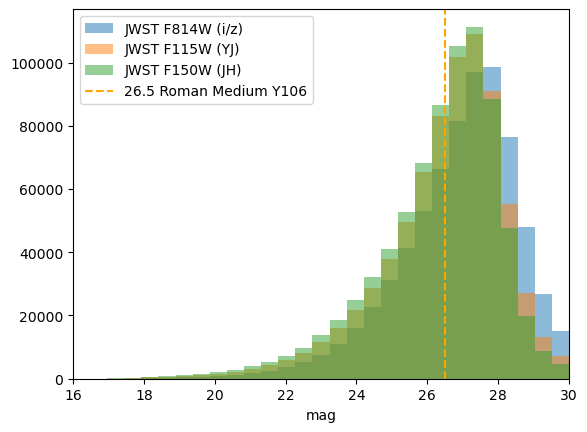

In [10]:
### Show the magnitude distribution in the relevant bands (F814W, F115W, F150W) to understand how many galaxies are bright enough for shape measurements.
mag_bins = np.linspace(16, 30, 30)
plt.hist(catalog_c25["mag_model_hst-f814w"], bins=mag_bins, label='JWST F814W (i/z)', alpha=0.5)
plt.hist(catalog_c25["mag_model_f115w"], bins=mag_bins, label='JWST F115W (YJ)', alpha=0.5)
plt.hist(catalog_c25["mag_model_f150w"], bins=mag_bins, label='JWST F150W (JH)', alpha=0.5)
plt.axvline(26.5, color='orange', linestyle='--', label='26.5 Roman Medium Y106')
plt.xlabel("mag")
plt.legend()
plt.xlim(16, 30)
plt.show()

As we can see, the COSMOS2025 catalog is deep enough in zYJH band. Although their r-band is not deep enough, we might be able to use F814W to approximate r-band Luminosity and use the scaling relation in Fabian's paper. 

In [11]:
Area_C25 = 0.43 * 3600 # arcmin2, effective area of COSMOS-Web after masking in JWST/NIRCam

R_space_F150W = get_spatial_resolution_factor(catalog_c25_phot, ROMAN_EFF50PSF)
shape_err = get_shape_measurement_error(catalog_c25_phot)
IS_GALAXY = catalog_c25_photoz["type"]==0
HA_IN_GRISM = (emission_line_results["lambda_Ha_obs"] > ROMAN_GRISM_WAVE_MIN.to('Angstrom').value) & \
              (emission_line_results["lambda_Ha_obs"] < ROMAN_GRISM_WAVE_MAX.to('Angstrom').value)
OII_IN_GRISM = (emission_line_results["lambda_OII_obs"] > ROMAN_GRISM_WAVE_MIN.to('Angstrom').value) & \
              (emission_line_results["lambda_OII_obs"] < ROMAN_GRISM_WAVE_MAX.to('Angstrom').value)
OIII_IN_GRISM = (emission_line_results["lambda_OIII_obs"] > ROMAN_GRISM_WAVE_MIN.to('Angstrom').value) & \
              (emission_line_results["lambda_OIII_obs"] < ROMAN_GRISM_WAVE_MAX.to('Angstrom').value)

### Selecting Roman Deep Sample
SNR_F150W_ROMAN_DEEP = get_SNR_image(catalog_c25_phot, 'f150w', ROMAN_DEEP_JH_DEPTH)

roman_deep = (SNR_F150W_ROMAN_DEEP > JH_SNR_THRESHOLD) & \
             (R_space_F150W > R_SPATIAL_THRESHOLD) & \
             (shape_err < SHAPE_ERROR_THRESHOLD) & \
             IS_GALAXY & \
             (\
                ((emission_line_results["F_Ha"] > ROMAN_DEEP_GRISM_DEPTH.to('erg/s/cm^2').value) & HA_IN_GRISM) | \
                ((emission_line_results["F_OII"] > ROMAN_DEEP_GRISM_DEPTH.to('erg/s/cm^2').value) & OII_IN_GRISM) | \
                ((emission_line_results["F_OIII"] > ROMAN_DEEP_GRISM_DEPTH.to('erg/s/cm^2').value) & OIII_IN_GRISM) \
             )
print(f'Roman Deep Tier Sample: number density = {roman_deep.sum()/Area_C25:.4f} gal/arcmin^2')

### Selecting Roman Medium Sample
SNR_F150W_ROMAN_MEDIUM = get_SNR_image(catalog_c25_phot, 'f150w', ROMAN_MEDIUM_JH_DEPTH)

roman_medium = (SNR_F150W_ROMAN_MEDIUM > JH_SNR_THRESHOLD) & \
               (R_space_F150W > R_SPATIAL_THRESHOLD) & \
               (shape_err < SHAPE_ERROR_THRESHOLD) & \
               IS_GALAXY & \
               (\
                  ((emission_line_results["F_Ha"] > ROMAN_MEDIUM_GRISM_DEPTH.to('erg/s/cm^2').value) & HA_IN_GRISM) | \
                  ((emission_line_results["F_OII"] > ROMAN_MEDIUM_GRISM_DEPTH.to('erg/s/cm^2').value) & OII_IN_GRISM) | \
                  ((emission_line_results["F_OIII"] > ROMAN_MEDIUM_GRISM_DEPTH.to('erg/s/cm^2').value) & OIII_IN_GRISM) \
               )

print(f'Roman Medium Tier Sample: number density = {roman_medium.sum()/Area_C25:.4f} gal/arcmin^2')

Roman Deep Tier Sample: number density = 12.3004 gal/arcmin^2
Roman Medium Tier Sample: number density = 5.7377 gal/arcmin^2


In [12]:
### Selecting Roman redMaGiC Sample 
# As a reference, DES Y3 redMaGiC sample has a number density of ~ 0.174 gal/arcmin^2 
# with a photo-z scatter of 閿滅禆z ~ 0.015 and outlier rate of ~ 1% at z~0.5-0.9 
# (see https://arxiv.org/abs/2105.13547).
### (Medium tier)
IS_REDMAGIC_MEDIUM = realistic_roman_redmagic(catalog_c25_photoz, 
                             assume_roman_photoz=True,
                             roman_photoz_error_floor=0.02,
                             z_min=0., z_max=4,
                             max_log_ssfr=-10.5, min_log_mass=10.3, l_min=0.5)

roman_redmagic_medium = (SNR_F150W_ROMAN_MEDIUM > JH_SNR_THRESHOLD) & \
               (R_space_F150W > R_SPATIAL_THRESHOLD) & \
               (shape_err < SHAPE_ERROR_THRESHOLD) & \
               IS_GALAXY & \
               IS_REDMAGIC_MEDIUM
print(f'Roman Medium Tier redMaGiC Sample: number density = {roman_redmagic_medium.sum()/Area_C25:.4f} gal/arcmin^2')

### (Wide tier)
IS_REDMAGIC_WIDE = realistic_roman_redmagic(catalog_c25_photoz, 
                             assume_roman_photoz=True,
                             roman_photoz_error_floor=0.03,
                             z_min=0.2, z_max=4,
                             max_log_ssfr=-10.5, min_log_mass=10.3, l_min=0.5)

roman_redmagic_wide = (SNR_F150W_ROMAN_MEDIUM > JH_SNR_THRESHOLD) & \
               (R_space_F150W > R_SPATIAL_THRESHOLD) & \
               (shape_err < SHAPE_ERROR_THRESHOLD) & \
               IS_GALAXY & \
               IS_REDMAGIC_WIDE
print(f'Roman Wide Tier redMaGiC Sample: number density = {roman_redmagic_wide.sum()/Area_C25:.4f} gal/arcmin^2')


Roman Medium Tier redMaGiC Sample: number density = 1.4193 gal/arcmin^2
Roman Wide Tier redMaGiC Sample: number density = 0.3786 gal/arcmin^2


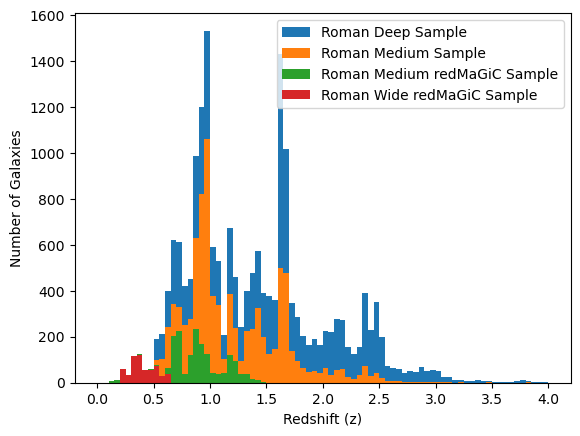

In [13]:
nbins = 81
plt.hist(catalog_c25_photoz['zfinal'][roman_deep], bins=np.linspace(0, 4, nbins), label='Roman Deep Sample')
plt.hist(catalog_c25_photoz['zfinal'][roman_medium], bins=np.linspace(0, 4, nbins), label='Roman Medium Sample')
plt.hist(catalog_c25_photoz['zfinal'][roman_redmagic_medium], bins=np.linspace(0, 4, nbins), label='Roman Medium redMaGiC Sample')
plt.hist(catalog_c25_photoz['zfinal'][roman_redmagic_wide], bins=np.linspace(0, 4, nbins), label='Roman Wide redMaGiC Sample')
plt.xlabel('Redshift (z)')
plt.ylabel('Number of Galaxies')
plt.legend()
plt.show()


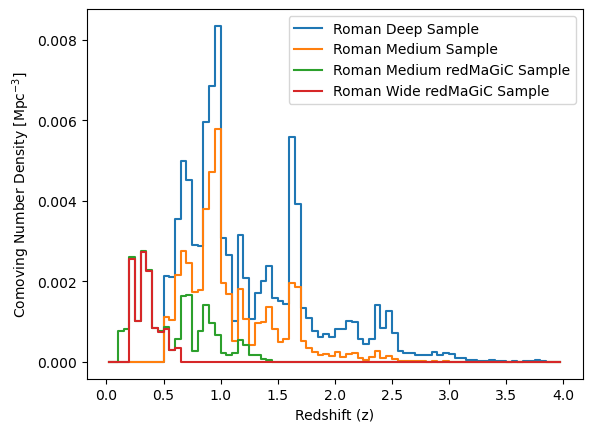

In [14]:
# Convert galaxy counts to comoving number density n(z) [Mpc^-3]
bins = np.linspace(0, 4, nbins)
z_mid = 0.5 * (bins[:-1] + bins[1:])

# Area_C25 is in arcmin^2; convert to steradian
area_sr = (Area_C25 / 3600.0) * (np.pi / 180.0)**2
dc_edges = Planck15.comoving_distance(bins).value  # Mpc
shell_vol = (area_sr / 3.0) * (dc_edges[1:]**3 - dc_edges[:-1]**3)  # Mpc^3

samples = {
    'Roman Deep Sample': roman_deep,
    'Roman Medium Sample': roman_medium,
    'Roman Medium redMaGiC Sample': roman_redmagic_medium,
    'Roman Wide redMaGiC Sample': roman_redmagic_wide,
}

for label, mask in samples.items():
    counts, _ = np.histogram(catalog_c25_photoz['zfinal'][mask], bins=bins)
    n_of_z = counts / shell_vol
    plt.step(z_mid, n_of_z, where='mid', label=label)

plt.xlabel('Redshift (z)')
plt.ylabel(r'Comoving Number Density [Mpc$^{-3}$]')
plt.legend()
plt.show()


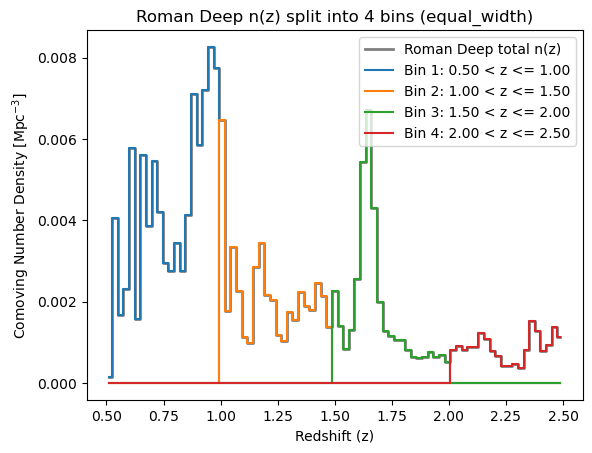

In [15]:
# separate nz bins (updated 2026-02-24): Roman Deep n(z) with user-controlled bin count
num_density_bins = 81  # resolution of the n(z) curve
num_tomo_bins = 4      # user control: number of redshift bins
binning_mode = 'equal_width'  # 'equal_width' or 'equal_number'
z_min, z_max = 0.5, 2.50

z_deep = np.asarray(catalog_c25_photoz['zfinal'][roman_deep])
valid = np.isfinite(z_deep) & (z_deep >= z_min) & (z_deep <= z_max)
z_deep = z_deep[valid]

# Area_C25 is in arcmin^2; convert to steradian
area_sr = (Area_C25 / 3600.0) * (np.pi / 180.0)**2

# High-resolution total n(z)
density_edges = np.linspace(z_min, z_max, num_density_bins + 1)
z_mid = 0.5 * (density_edges[:-1] + density_edges[1:])
dc_edges = Planck15.comoving_distance(density_edges).value  # Mpc
shell_vol = (area_sr / 3.0) * (dc_edges[1:]**3 - dc_edges[:-1]**3)  # Mpc^3
counts_total, _ = np.histogram(z_deep, bins=density_edges)
n_of_z_total = counts_total / shell_vol

# Tomographic bin edges controlled by num_tomo_bins
if binning_mode == 'equal_number':
    tomo_edges = np.quantile(z_deep, np.linspace(0.0, 1.0, num_tomo_bins + 1))
    tomo_edges[0], tomo_edges[-1] = z_min, z_max
else:
    tomo_edges = np.linspace(z_min, z_max, num_tomo_bins + 1)

plt.step(z_mid, n_of_z_total, where='mid', color='k', lw=2, alpha=0.5,
         label='Roman Deep total n(z)')
for i in range(num_tomo_bins):
    lo, hi = tomo_edges[i], tomo_edges[i + 1]
    if i < num_tomo_bins - 1:
        in_bin = (z_mid >= lo) & (z_mid < hi)
    else:
        in_bin = (z_mid >= lo) & (z_mid <= hi)
    n_of_z_bin = np.where(in_bin, n_of_z_total, 0.0)
    plt.step(z_mid, n_of_z_bin, where='mid',
             label=f'Bin {i+1}: {lo:.2f} < z <= {hi:.2f}')
    #np.savez("./Roman_Deep_bin"+str(int(i+1))+".npz",z_mid,n_of_z_bin)
    #np.savez("./Roman_Medium.npz",z_mid,n_of_z_bin)

plt.xlabel('Redshift (z)')
plt.ylabel(r'Comoving Number Density [Mpc$^{-3}$]')
plt.title(f'Roman Deep n(z) split into {num_tomo_bins} bins ({binning_mode})')
plt.legend()
plt.show()


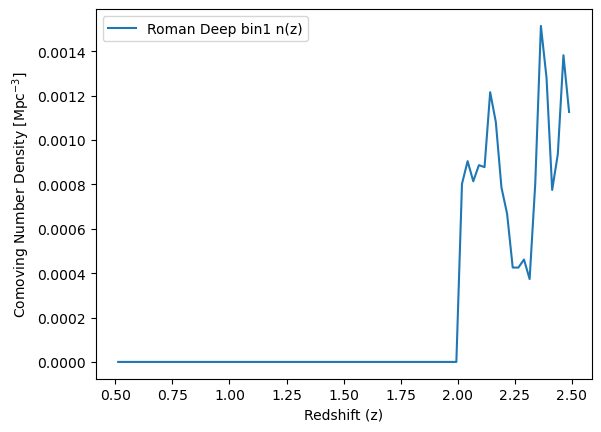

z_eff =  2.2747335166250626
Average galaxy density nbar_bin Mpc^-3 = 0.0008727268313027307 Mpc3


In [65]:
# test

z_bin1 = np.load("./Roman_Deep_bin4.npz")["arr_0"]   # z midpoints
nz_bin1 = np.load("./Roman_Deep_bin4.npz")["arr_1"]  # comoving number density [Mpc^-3]

plt.plot(z_bin1, nz_bin1, label="Roman Deep bin1 n(z)")
plt.xlabel("Redshift (z)")
plt.ylabel(r"Comoving Number Density [Mpc$^{-3}$]")
plt.legend()
plt.show()

area_arcmin2 = Area_C25
area_sr = (area_arcmin2 / 3600.0) * (np.pi / 180.0)**2

# n(z)^2-weighted effective redshift (你原来的量)
z_eff = np.trapezoid(z_bin1 * nz_bin1**2, z_bin1) / np.trapezoid(nz_bin1**2, z_bin1)
print("z_eff = ", z_eff)

mask = np.where( nz_bin1 > 0 )
chi_array = cosmo.comoving_distance(z_bin1[mask])
dchidz = np.gradient(chi_array,z_bin1[mask])
Vs = np.trapezoid( area_sr*chi_array**2*dchidz,z_bin1[mask] )
Vs = Vs.value
N_gal = np.trapezoid( nz_bin1[mask]*area_sr*chi_array**2*dchidz,z_bin1[mask] )
N_gal.value

# 平均星系密度
nbar_bin = N_gal / Vs

print("Average galaxy density nbar_bin Mpc^-3 =", nbar_bin)


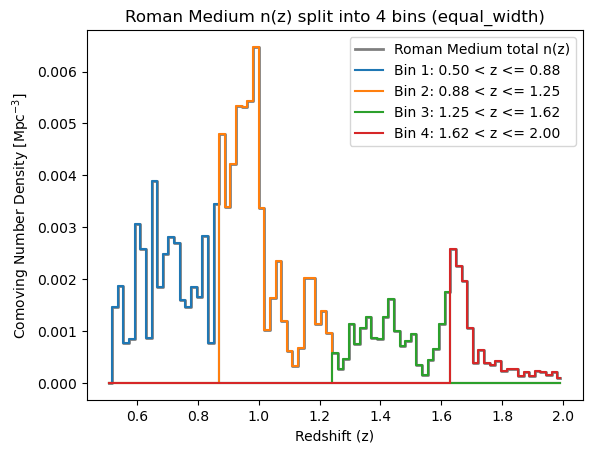

In [17]:
# separate nz bins (updated 2026-02-24): Roman Deep n(z) with user-controlled bin count
num_density_bins = 81  # resolution of the n(z) curve
num_tomo_bins = 4      # user control: number of redshift bins
binning_mode = 'equal_width'  # 'equal_width' or 'equal_number'
z_min, z_max = 0.5, 2.0

z_deep = np.asarray(catalog_c25_photoz['zfinal'][roman_medium])
valid = np.isfinite(z_deep) & (z_deep >= z_min) & (z_deep <= z_max)
z_deep = z_deep[valid]

# Area_C25 is in arcmin^2; convert to steradian
area_sr = (Area_C25 / 3600.0) * (np.pi / 180.0)**2

# High-resolution total n(z)
density_edges = np.linspace(z_min, z_max, num_density_bins + 1)
z_mid = 0.5 * (density_edges[:-1] + density_edges[1:])
dc_edges = Planck15.comoving_distance(density_edges).value  # Mpc
shell_vol = (area_sr / 3.0) * (dc_edges[1:]**3 - dc_edges[:-1]**3)  # Mpc^3
counts_total, _ = np.histogram(z_deep, bins=density_edges)
n_of_z_total = counts_total / shell_vol

# Tomographic bin edges controlled by num_tomo_bins
if binning_mode == 'equal_number':
    tomo_edges = np.quantile(z_deep, np.linspace(0.0, 1.0, num_tomo_bins + 1))
    tomo_edges[0], tomo_edges[-1] = z_min, z_max
else:
    tomo_edges = np.linspace(z_min, z_max, num_tomo_bins + 1)

plt.step(z_mid, n_of_z_total, where='mid', color='k', lw=2, alpha=0.5,
         label='Roman Medium total n(z)')
for i in range(num_tomo_bins):
    lo, hi = tomo_edges[i], tomo_edges[i + 1]
    if i < num_tomo_bins - 1:
        in_bin = (z_mid >= lo) & (z_mid < hi)
    else:
        in_bin = (z_mid >= lo) & (z_mid <= hi)
    n_of_z_bin = np.where(in_bin, n_of_z_total, 0.0)
    plt.step(z_mid, n_of_z_bin, where='mid',
             label=f'Bin {i+1}: {lo:.2f} < z <= {hi:.2f}')
    #np.savez("./Roman_Medium_bin"+str(int(i+1))+".npz",z_mid,n_of_z_bin)
    #np.savez("./Roman_Medium.npz",z_mid,n_of_z_bin)

plt.xlabel('Redshift (z)')
plt.ylabel(r'Comoving Number Density [Mpc$^{-3}$]')
plt.title(f'Roman Medium n(z) split into {num_tomo_bins} bins ({binning_mode})')
plt.legend()
plt.show()


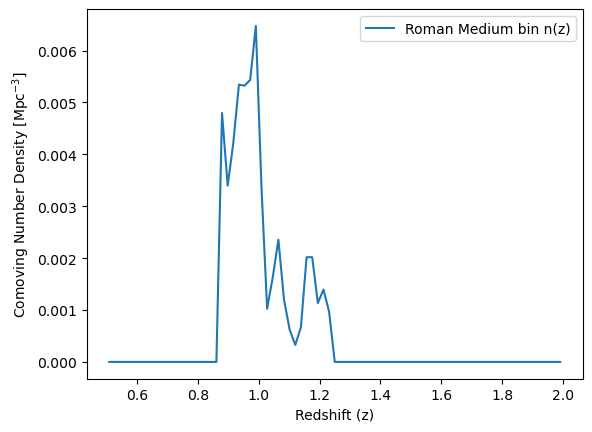

z_eff =  0.968928163956915
Average galaxy density nbar_bin Mpc^-3 = 0.002560563413501805 Mpc3


In [87]:
# test

z_bin1 = np.load("./Roman_Medium_bin2.npz")["arr_0"]   # z midpoints
nz_bin1 = np.load("./Roman_Medium_bin2.npz")["arr_1"]  # comoving number density [Mpc^-3]

plt.plot(z_bin1, nz_bin1, label="Roman Medium bin n(z)")
plt.xlabel("Redshift (z)")
plt.ylabel(r"Comoving Number Density [Mpc$^{-3}$]")
plt.legend()
plt.show()

area_arcmin2 = Area_C25
area_sr = (area_arcmin2 / 3600.0) * (np.pi / 180.0)**2

# n(z)^2-weighted effective redshift (你原来的量)
z_eff = np.trapezoid(z_bin1 * nz_bin1**2, z_bin1) / np.trapezoid(nz_bin1**2, z_bin1)
print("z_eff = ", z_eff)

mask = np.where( nz_bin1 > 0 )
chi_array = cosmo.comoving_distance(z_bin1[mask])
dchidz = np.gradient(chi_array,z_bin1[mask])
Vs = np.trapezoid( area_sr*chi_array**2*dchidz,z_bin1[mask] )
Vs = Vs.value
N_gal = np.trapezoid( nz_bin1[mask]*area_sr*chi_array**2*dchidz,z_bin1[mask] )
N_gal.value

# 平均星系密度
nbar_bin = N_gal / Vs

print("Average galaxy density nbar_bin Mpc^-3 =", nbar_bin)


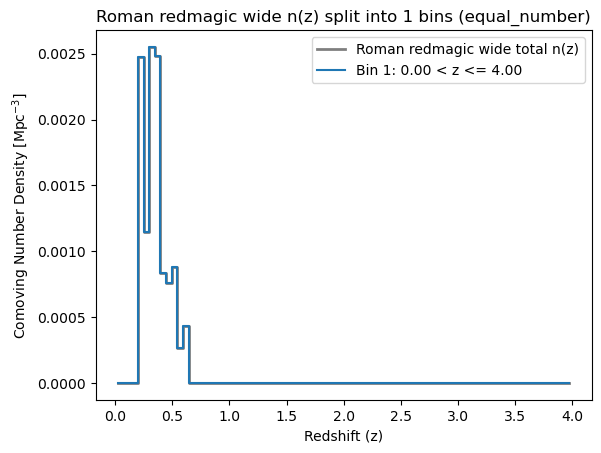

In [19]:
# separate nz bins (updated 2026-02-24): Roman Deep n(z) with user-controlled bin count
num_density_bins = 81  # resolution of the n(z) curve
num_tomo_bins = 1      # user control: number of redshift bins
binning_mode = 'equal_number'  # 'equal_width' or 'equal_number'
z_min, z_max = 0.0, 4.0

z_deep = np.asarray(catalog_c25_photoz['zfinal'][roman_redmagic_wide])
valid = np.isfinite(z_deep) & (z_deep >= z_min) & (z_deep <= z_max)
z_deep = z_deep[valid]

# Area_C25 is in arcmin^2; convert to steradian
area_sr = (Area_C25 / 3600.0) * (np.pi / 180.0)**2

# High-resolution total n(z)
density_edges = np.linspace(z_min, z_max, num_density_bins + 1)
z_mid = 0.5 * (density_edges[:-1] + density_edges[1:])
dc_edges = Planck15.comoving_distance(density_edges).value  # Mpc
shell_vol = (area_sr / 3.0) * (dc_edges[1:]**3 - dc_edges[:-1]**3)  # Mpc^3
counts_total, _ = np.histogram(z_deep, bins=density_edges)
n_of_z_total = counts_total / shell_vol

# Tomographic bin edges controlled by num_tomo_bins
if binning_mode == 'equal_number':
    tomo_edges = np.quantile(z_deep, np.linspace(0.0, 1.0, num_tomo_bins + 1))
    tomo_edges[0], tomo_edges[-1] = z_min, z_max
else:
    tomo_edges = np.linspace(z_min, z_max, num_tomo_bins + 1)

plt.step(z_mid, n_of_z_total, where='mid', color='k', lw=2, alpha=0.5,
         label='Roman redmagic wide total n(z)')
for i in range(num_tomo_bins):
    lo, hi = tomo_edges[i], tomo_edges[i + 1]
    if i < num_tomo_bins - 1:
        in_bin = (z_mid >= lo) & (z_mid < hi)
    else:
        in_bin = (z_mid >= lo) & (z_mid <= hi)
    n_of_z_bin = np.where(in_bin, n_of_z_total, 0.0)
    plt.step(z_mid, n_of_z_bin, where='mid',
             label=f'Bin {i+1}: {lo:.2f} < z <= {hi:.2f}')
    #np.savez("./Roman_redmagic_wide_bin"+str(int(i+1))+".npz",z_mid,n_of_z_bin)
    #np.savez("./Roman_Deep.npz",z_mid,n_of_z_bin)

plt.xlabel('Redshift (z)')
plt.ylabel(r'Comoving Number Density [Mpc$^{-3}$]')
plt.title(f'Roman redmagic wide n(z) split into {num_tomo_bins} bins ({binning_mode})')
plt.legend()
plt.show()


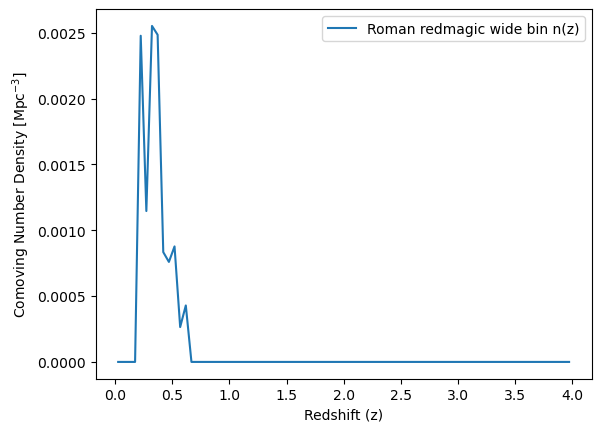

z_eff =  0.3215198374730745
Average galaxy density nbar_bin Mpc^-3 = 0.0010380001960799343 Mpc3


In [20]:
# test

z_bin1 = np.load("./Roman_redmagic_wide_bin1.npz")["arr_0"]   # z midpoints
nz_bin1 = np.load("./Roman_redmagic_wide_bin1.npz")["arr_1"]  # comoving number density [Mpc^-3]

plt.plot(z_bin1, nz_bin1, label="Roman redmagic wide bin n(z)")
plt.xlabel("Redshift (z)")
plt.ylabel(r"Comoving Number Density [Mpc$^{-3}$]")
plt.legend()
plt.show()

area_arcmin2 = Area_C25
area_sr = (area_arcmin2 / 3600.0) * (np.pi / 180.0)**2

# n(z)^2-weighted effective redshift (你原来的量)
z_eff = np.trapezoid(z_bin1 * nz_bin1**2, z_bin1) / np.trapezoid(nz_bin1**2, z_bin1)
print("z_eff = ", z_eff)

mask = np.where( nz_bin1 > 0 )
chi_array = cosmo.comoving_distance(z_bin1[mask])
dchidz = np.gradient(chi_array,z_bin1[mask])
Vs = np.trapezoid( area_sr*chi_array**2*dchidz,z_bin1[mask] )
Vs = Vs.value
N_gal = np.trapezoid( nz_bin1[mask]*area_sr*chi_array**2*dchidz,z_bin1[mask] )
N_gal.value

# 平均星系密度
nbar_bin = N_gal / Vs

print("Average galaxy density nbar_bin Mpc^-3 =", nbar_bin)


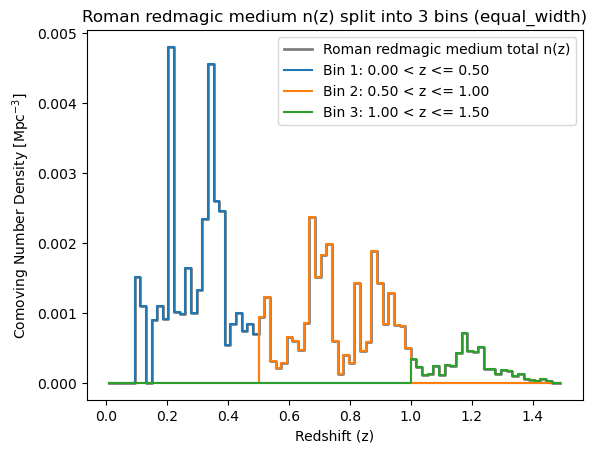

In [ ]:
# separate nz bins (updated 2026-02-24): Roman redmagic medium n(z) with user-controlled bin count
num_density_bins = 81  # resolution of the n(z) curve
num_tomo_bins = 3      # user control: number of redshift bins
binning_mode = 'equal_width'  # 'equal_width' or 'equal_number'
z_min, z_max = 0.0, 1.50

z_deep = np.asarray(catalog_c25_photoz['zfinal'][roman_redmagic_medium])
valid = np.isfinite(z_deep) & (z_deep >= z_min) & (z_deep <= z_max)
z_deep = z_deep[valid]

# Area_C25 is in arcmin^2; convert to steradian
area_sr = (Area_C25 / 3600.0) * (np.pi / 180.0)**2

# High-resolution total n(z)
density_edges = np.linspace(z_min, z_max, num_density_bins + 1)
z_mid = 0.5 * (density_edges[:-1] + density_edges[1:])
dc_edges = Planck15.comoving_distance(density_edges).value  # Mpc
shell_vol = (area_sr / 3.0) * (dc_edges[1:]**3 - dc_edges[:-1]**3)  # Mpc^3
counts_total, _ = np.histogram(z_deep, bins=density_edges)
n_of_z_total = counts_total / shell_vol

# Tomographic bin edges controlled by num_tomo_bins
if binning_mode == 'equal_number':
    tomo_edges = np.quantile(z_deep, np.linspace(0.0, 1.0, num_tomo_bins + 1))
    tomo_edges[0], tomo_edges[-1] = z_min, z_max
else:
    tomo_edges = np.linspace(z_min, z_max, num_tomo_bins + 1)

plt.step(z_mid, n_of_z_total, where='mid', color='k', lw=2, alpha=0.5,
         label='Roman redmagic medium total n(z)')
for i in range(num_tomo_bins):
    lo, hi = tomo_edges[i], tomo_edges[i + 1]
    if i < num_tomo_bins - 1:
        in_bin = (z_mid >= lo) & (z_mid < hi)
    else:
        in_bin = (z_mid >= lo) & (z_mid <= hi)
    n_of_z_bin = np.where(in_bin, n_of_z_total, 0.0)
    plt.step(z_mid, n_of_z_bin, where='mid',
             label=f'Bin {i+1}: {lo:.2f} < z <= {hi:.2f}')
    #np.savez("./Roman_redmagic_medium_bin"+str(int(i+1))+".npz",z_mid,n_of_z_bin)
    #np.savez("./Roman_Deep.npz",z_mid,n_of_z_bin)

plt.xlabel('Redshift (z)')
plt.ylabel(r'Comoving Number Density [Mpc$^{-3}$]')
plt.title(f'Roman redmagic medium n(z) split into {num_tomo_bins} bins ({binning_mode})')
plt.legend()
plt.show()


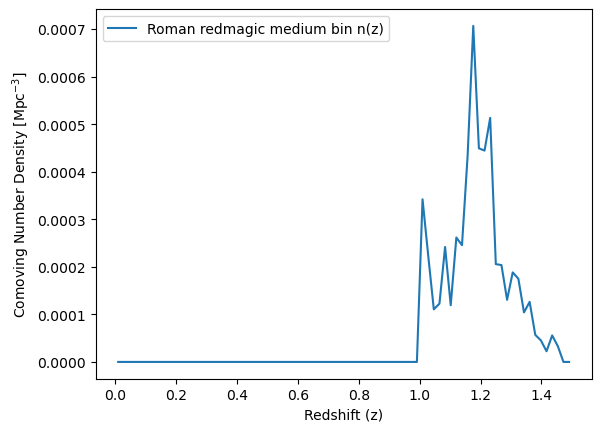

z_eff =  1.1782791075927577
Average galaxy density nbar_bin Mpc^-3 = 0.00021959342587208713 Mpc3


In [75]:
# test

z_bin1 = np.load("./Roman_redmagic_medium_bin3.npz")["arr_0"]   # z midpoints
nz_bin1 = np.load("./Roman_redmagic_medium_bin3.npz")["arr_1"]  # comoving number density [Mpc^-3]

plt.plot(z_bin1, nz_bin1, label="Roman redmagic medium bin n(z)")
plt.xlabel("Redshift (z)")
plt.ylabel(r"Comoving Number Density [Mpc$^{-3}$]")
plt.legend()
plt.show()

area_arcmin2 = Area_C25
area_sr = (area_arcmin2 / 3600.0) * (np.pi / 180.0)**2

# n(z)^2-weighted effective redshift (你原来的量)
z_eff = np.trapezoid(z_bin1 * nz_bin1**2, z_bin1) / np.trapezoid(nz_bin1**2, z_bin1)
print("z_eff = ", z_eff)

mask = np.where( nz_bin1 > 0 )
chi_array = cosmo.comoving_distance(z_bin1[mask])
dchidz = np.gradient(chi_array,z_bin1[mask])
Vs = np.trapezoid( area_sr*chi_array**2*dchidz,z_bin1[mask] )
Vs = Vs.value
N_gal = np.trapezoid( nz_bin1[mask]*area_sr*chi_array**2*dchidz,z_bin1[mask] )
N_gal.value

# 平均星系密度
nbar_bin = N_gal / Vs

print("Average galaxy density nbar_bin Mpc^-3 =", nbar_bin)


### Color and Luminosity Mapping

After we've selected the galaxy samples, we want to know their color (i.e. if they are red or blue), and their rest-frame r-band magnitude, to assign an IA amplitude for each galaxy

Related papers for such luminosity dependency:
- [Johnston et al. (2019)](https://arxiv.org/pdf/1811.09598): KiDS+GAMA
- [Singh et al. (2015)](https://arxiv.org/abs/1411.1755): SDSS-III BOSS LOW-Z
- [Samuroff et al. (2023)](https://arxiv.org/abs/2212.11319): DES x eBOSS
- [Hevars Peters et al. (2025)](https://arxiv.org/abs/2412.01790): UNIONS x eBOSS
- [Siegle et al. (2025)](https://arxiv.org/abs/2507.11530): DESI


**WARNING**: The code below only use placeholders $A(L,z)$ amplitude and luminosity power-law index and pivot luminosity. Need to replace the true numbers from some of the papers above.

In [39]:
def classify_red_blue_galaxies(catalog_data_photoz, method='color', inclusive=2):
    """
    Classify galaxies as red/blue for intrinsic alignment studies
    using LEPHARE rest-frame absolute magnitudes
    
    Parameters:
    -----------
    catalog_data_photoz : dict or Table
        COSMOS-Web catalog with LEPHARE columns:
        - zfinal: photometric redshift
        - mabs_nuv: NUV absolute magnitude
        - mabs_r: r-band absolute magnitude  
        - mabs_j: J-band absolute magnitude
        - mabs_k: K-band absolute magnitude
        - ssfr_med: specific star formation rate [1/yr]
        - mass_med: stellar mass [M_sol]
    
    method : str
        'color': Use rest-frame colors (NUV-r or r-J)
        'ssfr': Use specific star formation rate
    
    inclusive : int
        Flag for target selection strictness, 0-2 with increasing inclusiveness:
        0: quiescent galaxy cut: (NUV 闁?r) > 3 閼?(r 闁?J) + 1 and (NUV 闁?r) > 3.1
        1: conservative cuts
        2: standard cuts (more inclusive)

    
    Returns:
    --------
    results : dict
        'is_red': bool array, red galaxy mask
        'is_blue': bool array, blue galaxy mask  
        'UV_color': rest-frame color proxy
        'selection_stats': dictionary with statistics
    """
    results = {}
    # Extract catalog columns
    M_NUV = np.array(catalog_data_photoz['mabs_nuv'])
    M_r = np.array(catalog_data_photoz['mabs_r'])
    M_J = np.array(catalog_data_photoz['mabs_j'])
    M_K = np.array(catalog_data_photoz['mabs_k'])
    log_ssfr = np.array(catalog_data_photoz['ssfr_med'])
    log_mass = np.array(catalog_data_photoz['mass_med'])
    z = np.array(catalog_data_photoz['zfinal'])
    
    # =========================================================================
    # Method 1: Rest-frame color
    # =========================================================================
    
    # NUV - r is excellent proxy for U - V
    # (NUV ~ U, r-band straddles U and V)
    NUVr_color = M_NUV - M_r
    
    # Alternative: r - J also separates red/blue
    rJ_color = M_r - M_J
    
    # Red sequence evolution (Williams+09, Whitaker+11)
    # (U-V)_red = 1.0 + 0.18*z for passive galaxies
    # We use NUV-r which is similar
    NUVr_threshold = 3.5 + 0.2 * z  # NUV-r ~ (U-V) + 2.5
    
    # Alternative threshold: r-J (less scatter)
    rJ_threshold = 0.8 + 0.1 * z
    
    if inclusive == 0:
        # Strict color cut
        # (NUV 闁?r) > 3 閼?(r 闁?J) + 1 and (NUV 闁?r) > 3.1
        red_color_NUVr = NUVr_color > 3.1
        red_color_rJ = NUVr_color > 3 * rJ_color + 1
    elif inclusive == 1:
        # Strict color cut
        red_color_NUVr = NUVr_color > NUVr_threshold + 0.3
        red_color_rJ = rJ_color > rJ_threshold + 0.1
    else:
        # Standard cut
        red_color_NUVr = NUVr_color > NUVr_threshold
        red_color_rJ = rJ_color > rJ_threshold
    
    # Combine (require both to be safe)
    red_color = red_color_NUVr & red_color_rJ
    
    # =========================================================================
    # Method 2: sSFR-based
    # =========================================================================
    
    if inclusive == 0 or inclusive == 1:
        quiescent = log_ssfr < -11.0
    else:
        quiescent = log_ssfr < -10.5
    
    # Valid photometry
    valid_phot = (
        np.isfinite(M_NUV) & np.isfinite(M_r) & 
        np.isfinite(M_J) & np.isfinite(M_K) &
        (M_r > -30) & (M_r < -10)  # Sanity checks
    )
    
    # =========================================================================
    # Final selections
    # =========================================================================
    
    if method == 'color':
        is_red = red_color & valid_phot
        
    elif method == 'ssfr':
        is_red = quiescent & valid_phot
    
    else:
        raise ValueError("method must be 'color', 'ssfr', or 'combined'")
    
    # Blue galaxies: opposite of red
    # For IA context: star-forming, lower mass
    is_blue = (
        (log_ssfr > -10.5) &     # Star-forming
        (log_mass > 9.5)       # Not too low mass
    )
    
    # =========================================================================
    # Statistics
    # =========================================================================
    
    selection_stats = {
        'n_total': len(z),
        'n_red': np.sum(is_red),
        'n_blue': np.sum(is_blue),
        'frac_red': np.sum(is_red) / len(z),
        'frac_blue': np.sum(is_blue) / len(z),
    }
    
    results = {
        'is_red': is_red,
        'is_blue': is_blue,
        'NUVr_color': NUVr_color,
        'rJ_color': rJ_color,
        'log_ssfr': log_ssfr,
        'quiescent': quiescent,
        'selection_stats': selection_stats
    }
    
    return results


# =========================================================================
# IA Amplitude Estimation for Red Galaxies
# =========================================================================

def estimate_IA_amplitude(M_r, redshift, 
                          model='singh15',
                          return_uncertainty=True):
    """
    Estimate intrinsic alignment amplitude for red galaxies
    based on luminosity-dependence
    
    Parameters:
    -----------
    M_r : array-like
        Rest-frame r-band absolute magnitude
    redshift : array-like
        Redshift
    model : str
        'singh15': Singh et al. (2015) - BOSS LOWZ
        'johnston19': Johnston et al. (2019) - BOSS LOWZ/CMASS
        'joachimi11': Joachimi et al. (2011) - MegaZ LRG + SDSS LRG
    return_uncertainty : bool
        Return uncertainty on A_IA estimate
    
    Returns:
    --------
    A_IA : array-like
        Intrinsic alignment amplitude
    A_IA_err : array-like (optional)
        Uncertainty on A_IA
    
    Notes:
    ------
    The IA amplitude in the linear alignment model:
    P_IA(k) = -A_IA 閼?C_1閿滅保crit 閼?閹剤m / D(z) 閼?P_閺堫亝婀?k)
    
    where C_1 閿滅保crit 闁?0.0134 for NLA model
    """
    
    M_r = np.asarray(M_r)
    redshift = np.asarray(redshift)
    
    if model == 'singh15':
        # Singh et al. (2015) - SDSS-III BOSS LOWZ sample
        # Median redshift z ~ 0.32
        # A_IA = A_1 閼?(L/L_0)^鐏忕斗n
        
        # Pivot magnitude: M_r,pivot = -22.0 (roughly L*)
        M_pivot = -22.0
        
        # Fiducial amplitude and slope
        A_1 = 4.9  # 閸?0.6
        beta = 1.3  # Luminosity dependence power-law index
        
        A_1_err = 0.6
        beta_err = 0.27
        
    elif model == 'johnston19':
        # Johnston et al. (2019) - BOSS LOWZ+CMASS
        # Updated constraints, similar parametrization
        
        M_pivot = -22.0
        A_1 = 3.4  # 閸?0.57 (for C_1 閿滅保crit normalization)
        beta = 0.18  # 閸?0.21 (stronger L-dependence)
        
        A_1_err = 0.57
        beta_err = 0.21
    
    elif model == 'joachimi11':
        # Joachimi et al. (2011) MegaZ LRG + SDSS LRG
        
        M_pivot = -22.0
        A_1 = 5.76  # Different normalization
        beta = 1.13

        A_1_err = .61
        beta_err = 0.23
    
    else:
        raise ValueError("model must be 'singh15', 'johnston19', or 'joachimi11'")
    
    # Calculate A_IA
    # L/L_0 = 10^(-0.4 * (M_r - M_pivot))
    # A_IA = A_1 閼?(L/L_0)^鐏?= A_1 閼?10^(-0.4 * 鐏?* (M_r - M_pivot))
    
    A_IA = A_1 * 10**(-0.4 * beta * (M_r - M_pivot))
    
    # Redshift evolution (weak, often neglected for z < 1)
    # A_IA 闁?(1+z)^閻? with 閻?~ -1 to 0
    # For simplicity, no z-evolution applied here
    
    if return_uncertainty:
        # Propagate uncertainties (approximate)
        A_IA_err = A_IA * np.sqrt(
            (A_1_err / A_1)**2 + 
            (beta_err * 0.4 * np.abs(M_r - M_pivot) * np.log(10))**2
        )
        return A_IA, A_IA_err
    else:
        return A_IA
    

def estimate_IA_amplitude_withz(M_r, redshift, 
                          model='singh15',
                          z_min=None, z_max=None,  # <--- 新增：红移控制参数
                          return_uncertainty=True):
    """
    Estimate intrinsic alignment amplitude for red galaxies
    based on luminosity-dependence.
    
    Parameters:
    -----------
    M_r : array-like
        Rest-frame r-band absolute magnitude
    redshift : array-like
        Redshift
    model : str
        'singh15', 'johnston19', or 'joachimi11'
    z_min : float, optional
        Minimum redshift threshold (inclusive)
    z_max : float, optional
        Maximum redshift threshold (inclusive)
    return_uncertainty : bool
        Return uncertainty on A_IA estimate
        
    Returns:
    --------
    A_IA : array-like
        Intrinsic alignment amplitude for filtered galaxies
    A_IA_err : array-like (optional)
        Uncertainty on A_IA for filtered galaxies
    valid_mask : array-like (bool)
        A boolean mask indicating which galaxies from the original input fell within the redshift range
    """
    
    M_r = np.asarray(M_r)
    redshift = np.asarray(redshift)
    
    # ==========================================
    # 新增：根据指定的红移范围生成掩码 (Mask)
    # ==========================================
    valid_mask = np.ones(len(redshift), dtype=bool) # 初始默认所有星系都有效
    
    if z_min is not None:
        valid_mask &= (redshift >= z_min)
    if z_max is not None:
        valid_mask &= (redshift <= z_max)
        
    # 应用掩码，只保留目标红移范围内的星系数据
    M_r_filtered = M_r[valid_mask]
    redshift_filtered = redshift[valid_mask]
    
    # 如果筛选后没有星系了，提前返回空数组
    if len(M_r_filtered) == 0:
        if return_uncertainty:
            return np.array([]), np.array([]), valid_mask
        else:
            return np.array([]), valid_mask

    # ==========================================
    # 原有的模型参数设定保持不变
    # ==========================================
    if model == 'singh15':
        M_pivot = -22.0
        A_1 = 4.9 
        beta = 1.3 
        A_1_err = 0.6
        beta_err = 0.27
    elif model == 'johnston19':
        M_pivot = -22.0
        A_1 = 3.4
        beta = 0.18
        A_1_err = 0.57
        beta_err = 0.21
    elif model == 'joachimi11':
        M_pivot = -22.0
        A_1 = 5.76 
        beta = 1.13
        A_1_err = 0.61
        beta_err = 0.23
    else:
        raise ValueError("model must be 'singh15', 'johnston19', or 'joachimi11'")
    
    # 计算被筛选出来的星系的 A_IA
    A_IA = A_1 * 10**(-0.4 * beta * (M_r_filtered - M_pivot))
    
    if return_uncertainty:
        # 计算误差
        A_IA_err = A_IA * np.sqrt(
            (A_1_err / A_1)**2 + 
            (beta_err * 0.4 * np.abs(M_r_filtered - M_pivot) * np.log(10))**2
        )
        # 多返回一个 valid_mask，方便外部对齐数据
        return A_IA, A_IA_err, valid_mask, M_r_filtered
    else:
        return A_IA, valid_mask, M_r_filtered

In [68]:
### IA amplitude for Roman Deep Sample
red_blue_classification_Roman_Deep = classify_red_blue_galaxies(
    catalog_c25_photoz[roman_deep], 
    method='color', inclusive=2
    )
print(f'Red galaxy fraction in Roman Deep Sample: {red_blue_classification_Roman_Deep["selection_stats"]["frac_red"]:.3f}')
print(f'Blue galaxy fraction in Roman Deep Sample: {red_blue_classification_Roman_Deep["selection_stats"]["frac_blue"]:.3f}')

zmin = 2.0
zmax = 2.5

IA_amplitude_Roman_Deep = estimate_IA_amplitude_withz(
    M_r=catalog_c25_photoz['mabs_r'][roman_deep][red_blue_classification_Roman_Deep['is_red']],
    redshift=catalog_c25_photoz['zfinal'][roman_deep][red_blue_classification_Roman_Deep['is_red']],
    z_min = zmin,
    z_max = zmax,
    model='johnston19',
    return_uncertainty=True
)

N_total = len( catalog_c25_photoz['mabs_r'][roman_deep] )
N_bin = np.sum( (catalog_c25_photoz['zfinal'][roman_deep] > zmin) & (catalog_c25_photoz['zfinal'][roman_deep] < zmax) )

print(f'Mean IA amplitude for the whole Roman Deep Sample: {IA_amplitude_Roman_Deep[0].sum()/N_bin:.3f}')
print(f'Mean IA amplitude for the red Roman Deep Sample bin: {IA_amplitude_Roman_Deep[0].sum()/len(IA_amplitude_Roman_Deep[0]):.3f}')

Red galaxy fraction in Roman Deep Sample: 0.086
Blue galaxy fraction in Roman Deep Sample: 0.784
Mean IA amplitude for the whole Roman Deep Sample: 0.068
Mean IA amplitude for the red Roman Deep Sample bin: 3.619


In [54]:
### IA amplitude for Roman Medium Sample
red_blue_classification_Roman_Medium = classify_red_blue_galaxies(
    catalog_c25_photoz[roman_medium], 
    method='color', inclusive=2
    )
print(f'Red galaxy fraction in Roman Medium Sample: {red_blue_classification_Roman_Medium["selection_stats"]["frac_red"]:.3f}')
print(f'Blue galaxy fraction in Roman Medium Sample: {red_blue_classification_Roman_Medium["selection_stats"]["frac_blue"]:.3f}')

zmin = 1.62
zmax = 2.0

IA_amplitude_Roman_Medium = estimate_IA_amplitude_withz(
    M_r=catalog_c25_photoz['mabs_r'][roman_medium][red_blue_classification_Roman_Medium['is_red']],
    redshift=catalog_c25_photoz['zfinal'][roman_medium][red_blue_classification_Roman_Medium['is_red']],
    z_min=zmin,
    z_max=zmax,
    model='johnston19',
    return_uncertainty=True
)

N_total = len( catalog_c25_photoz['mabs_r'][roman_medium] )
N_bin = np.sum( (catalog_c25_photoz['zfinal'][roman_medium] > zmin) & (catalog_c25_photoz['zfinal'][roman_medium] < zmax) )

print(f'Mean IA amplitude for the whole Roman Medium Sample: {IA_amplitude_Roman_Medium[0].sum()/N_bin:.2f}')
print(f'Mean IA amplitude for the red Roman Medium Sample: {IA_amplitude_Roman_Medium[0].sum()/len(IA_amplitude_Roman_Medium[0]):.2f}')

Red galaxy fraction in Roman Medium Sample: 0.107
Blue galaxy fraction in Roman Medium Sample: 0.906
Mean IA amplitude for the whole Roman Medium Sample: 0.25
Mean IA amplitude for the red Roman Medium Sample: 3.35


In [42]:
### IA amplitude for Roman Wide redMaGiC sample
red_blue_classification_Roman_redMaGiC_wide = classify_red_blue_galaxies(
    catalog_c25_photoz[roman_redmagic_wide], 
    method='color', inclusive=2
    )
print(f'Red galaxy fraction in Roman Wide Sample: {red_blue_classification_Roman_redMaGiC_wide["selection_stats"]["frac_red"]:.3f}')
print(f'Blue galaxy fraction in Roman Wide Sample: {red_blue_classification_Roman_redMaGiC_wide["selection_stats"]["frac_blue"]:.3f}')

IA_amplitude_Roman_Wide = estimate_IA_amplitude(
    M_r=catalog_c25_photoz['mabs_r'][roman_redmagic_wide][red_blue_classification_Roman_redMaGiC_wide['is_red']],
    redshift=catalog_c25_photoz['zfinal'][roman_redmagic_wide][red_blue_classification_Roman_redMaGiC_wide['is_red']],
    model='johnston19',
    return_uncertainty=True
)

print(f'Mean IA amplitude for the whole Roman Wide Sample: {IA_amplitude_Roman_Wide[0].sum()/roman_redmagic_wide.sum():.2f}')
print(f'Mean IA amplitude for the red Roman Wide Sample: {IA_amplitude_Roman_Wide[0].sum()/red_blue_classification_Roman_redMaGiC_wide["is_red"].sum():.2f}')

Red galaxy fraction in Roman Wide Sample: 0.923
Blue galaxy fraction in Roman Wide Sample: 0.000
Mean IA amplitude for the whole Roman Wide Sample: 3.10
Mean IA amplitude for the red Roman Wide Sample: 3.36


In [78]:
### IA amplitude for Roman Medium redMaGiC sample
red_blue_classification_Roman_redMaGiC_medium = classify_red_blue_galaxies(
    catalog_c25_photoz[roman_redmagic_medium], 
    method='color', inclusive=2
    )
print(f'Red galaxy fraction in Roman Medium Sample: {red_blue_classification_Roman_redMaGiC_medium["selection_stats"]["frac_red"]:.3f}')
print(f'Blue galaxy fraction in Roman Medium Sample: {red_blue_classification_Roman_redMaGiC_medium["selection_stats"]["frac_blue"]:.3f}')

zmin = 1.0
zmax = 1.5

IA_amplitude_Roman_Medium = estimate_IA_amplitude_withz(
    M_r=catalog_c25_photoz['mabs_r'][roman_redmagic_medium][red_blue_classification_Roman_redMaGiC_medium['is_red']],
    redshift=catalog_c25_photoz['zfinal'][roman_redmagic_medium][red_blue_classification_Roman_redMaGiC_medium['is_red']],
    z_min = zmin,
    z_max = zmax,
    model='johnston19',
    return_uncertainty=True
)

N_total = len( catalog_c25_photoz['mabs_r'][roman_redmagic_medium] )
N_bin = np.sum( (catalog_c25_photoz['zfinal'][roman_redmagic_medium] > zmin) 
               & (catalog_c25_photoz['zfinal'][roman_redmagic_medium] < zmax) )

print(f'Mean IA amplitude for the whole Roman redmagic Medium Sample: {IA_amplitude_Roman_Medium[0].sum()/N_bin:.2f}')
print(f'Mean IA amplitude for the red Roman redmagic Medium Sample: {IA_amplitude_Roman_Medium[0].sum()/len(IA_amplitude_Roman_Medium[0]):.2f}')

Red galaxy fraction in Roman Medium Sample: 0.887
Blue galaxy fraction in Roman Medium Sample: 0.000
Mean IA amplitude for the whole Roman redmagic Medium Sample: 2.89
Mean IA amplitude for the red Roman redmagic Medium Sample: 3.81


Roman Deep Tier KL Sample: number density = 1.7829 gal/arcmin^2
Roman Deep Tier WL Sample: number density = 7.9722 gal/arcmin^2


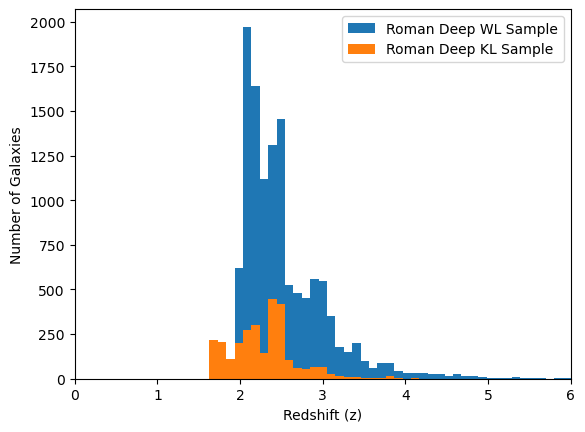

In [26]:
### Draft for doing something else: estimating kinematic lensing and weak lensing SNR for ~ Roman Deep Tier z>2.0
KL_EMISSION_OVERHEAD = 2
roman_deep_KL = (SNR_F150W_ROMAN_DEEP > JH_SNR_THRESHOLD) & \
             (R_space_F150W > R_SPATIAL_THRESHOLD) & \
             (shape_err < SHAPE_ERROR_THRESHOLD) & \
             IS_GALAXY & \
             (\
                #((emission_line_results["F_Ha"] > KL_EMISSION_OVERHEAD * ROMAN_DEEP_GRISM_DEPTH.to('erg/s/cm^2').value) & HA_IN_GRISM) | \
                ((emission_line_results["F_OII"] > KL_EMISSION_OVERHEAD * ROMAN_DEEP_GRISM_DEPTH.to('erg/s/cm^2').value) & OII_IN_GRISM)# | \
                #((emission_line_results["F_OIII"] > KL_EMISSION_OVERHEAD * ROMAN_DEEP_GRISM_DEPTH.to('erg/s/cm^2').value) & OIII_IN_GRISM) \
             )
print(f'Roman Deep Tier KL Sample: number density = {roman_deep_KL.sum()/Area_C25:.4f} gal/arcmin^2')

roman_deep_WL = (SNR_F150W_ROMAN_DEEP > JH_SNR_THRESHOLD) & \
             (R_space_F150W > R_SPATIAL_THRESHOLD) & \
             (shape_err < SHAPE_ERROR_THRESHOLD) & \
             IS_GALAXY & \
             (catalog_c25_photoz['zfinal'] > 2.0)
print(f'Roman Deep Tier WL Sample: number density = {roman_deep_WL.sum()/Area_C25:.4f} gal/arcmin^2')

### show the redshift distribution
plt.hist(catalog_c25_photoz['zfinal'][roman_deep_WL], bins=np.linspace(0, 6, 60), label='Roman Deep WL Sample')
plt.hist(catalog_c25_photoz['zfinal'][roman_deep_KL], bins=np.linspace(0, 6, 60), label='Roman Deep KL Sample')
plt.xlabel('Redshift (z)')
plt.ylabel('Number of Galaxies')
plt.legend()
plt.xlim(0, 6)
plt.show()


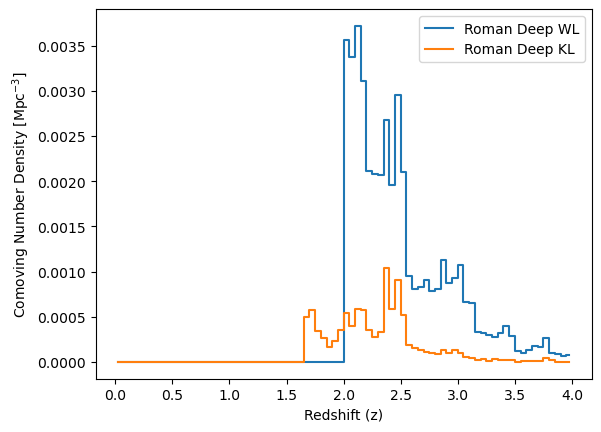

In [27]:
# Convert galaxy counts to comoving number density n(z) [Mpc^-3]
bins = np.linspace(0, 4, nbins)
z_mid = 0.5 * (bins[:-1] + bins[1:])

# Area_C25 is in arcmin^2; convert to steradian
area_sr = (Area_C25 / 3600.0) * (np.pi / 180.0)**2
dc_edges = Planck15.comoving_distance(bins).value  # Mpc
shell_vol = (area_sr / 3.0) * (dc_edges[1:]**3 - dc_edges[:-1]**3)  # Mpc^3

samples = {
    'Roman Deep WL': roman_deep_WL,
    'Roman Deep KL': roman_deep_KL,
}

for label, mask in samples.items():
    counts, _ = np.histogram(catalog_c25_photoz['zfinal'][mask], bins=bins)
    n_of_z = counts / shell_vol
    plt.step(z_mid, n_of_z, where='mid', label=label)

plt.xlabel('Redshift (z)')
plt.ylabel(r'Comoving Number Density [Mpc$^{-3}$]')
plt.legend()
plt.show()


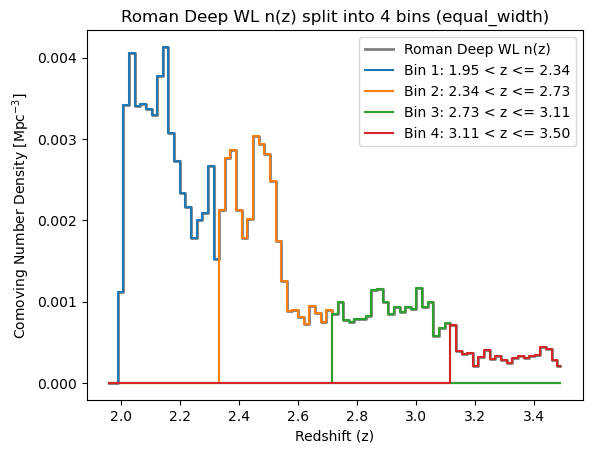

In [66]:
# separate nz bins (updated 2026-02-24): Roman Deep WL n(z) with user-controlled bin count
num_density_bins = 81  # resolution of the n(z) curve
num_tomo_bins = 4      # user control: number of redshift bins
binning_mode = 'equal_width'  # 'equal_width' or 'equal_number'
z_min, z_max = 1.95, 3.5

z_deep = np.asarray(catalog_c25_photoz['zfinal'][roman_deep_WL])
valid = np.isfinite(z_deep) & (z_deep >= z_min) & (z_deep <= z_max)
z_deep = z_deep[valid]

# Area_C25 is in arcmin^2; convert to steradian
area_sr = (Area_C25 / 3600.0) * (np.pi / 180.0)**2

# High-resolution total n(z)
density_edges = np.linspace(z_min, z_max, num_density_bins + 1)
z_mid = 0.5 * (density_edges[:-1] + density_edges[1:])
dc_edges = Planck15.comoving_distance(density_edges).value  # Mpc
shell_vol = (area_sr / 3.0) * (dc_edges[1:]**3 - dc_edges[:-1]**3)  # Mpc^3
counts_total, _ = np.histogram(z_deep, bins=density_edges)
n_of_z_total = counts_total / shell_vol

# Tomographic bin edges controlled by num_tomo_bins
if binning_mode == 'equal_number':
    tomo_edges = np.quantile(z_deep, np.linspace(0.0, 1.0, num_tomo_bins + 1))
    tomo_edges[0], tomo_edges[-1] = z_min, z_max
else:
    tomo_edges = np.linspace(z_min, z_max, num_tomo_bins + 1)

plt.step(z_mid, n_of_z_total, where='mid', color='k', lw=2, alpha=0.5,
         label='Roman Deep WL n(z)')
for i in range(num_tomo_bins):
    lo, hi = tomo_edges[i], tomo_edges[i + 1]
    if i < num_tomo_bins - 1:
        in_bin = (z_mid >= lo) & (z_mid < hi)
    else:
        in_bin = (z_mid >= lo) & (z_mid <= hi)
    n_of_z_bin = np.where(in_bin, n_of_z_total, 0.0)
    plt.step(z_mid, n_of_z_bin, where='mid',
             label=f'Bin {i+1}: {lo:.2f} < z <= {hi:.2f}')
    #np.savez("./Roman_DeepWL_bin"+str(int(i+1))+".npz",z_mid,n_of_z_bin)
    #np.savez("./Roman_DeepWL.npz",z_mid,n_of_z_bin)

plt.xlabel('Redshift (z)')
plt.ylabel(r'Comoving Number Density [Mpc$^{-3}$]')
plt.title(f'Roman Deep WL n(z) split into {num_tomo_bins} bins ({binning_mode})')
plt.legend()
plt.show()


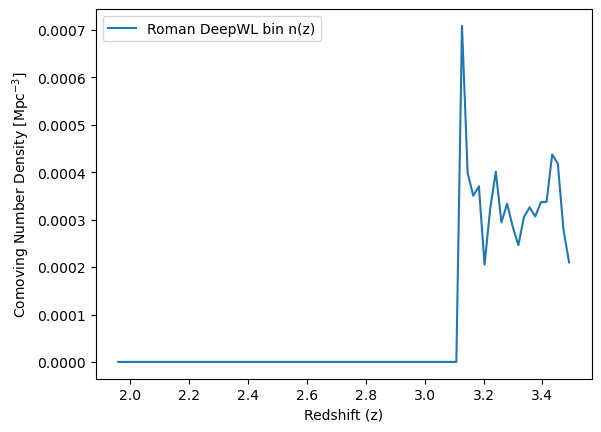

z_eff =  3.2765443953511046
Average galaxy density nbar_bin Mpc^-3 = 0.00033781350547272673 Mpc3


In [89]:
# Roman Deep WL

z_bin1 = np.load("./Roman_DeepWL_bin4.npz")["arr_0"]   # z midpoints
nz_bin1 = np.load("./Roman_DeepWL_bin4.npz")["arr_1"]  # comoving number density [Mpc^-3]

plt.plot(z_bin1, nz_bin1, label="Roman DeepWL bin n(z)")
plt.xlabel("Redshift (z)")
plt.ylabel(r"Comoving Number Density [Mpc$^{-3}$]")
plt.legend()
plt.show()

area_arcmin2 = Area_C25
area_sr = (area_arcmin2 / 3600.0) * (np.pi / 180.0)**2

# n(z)^2-weighted effective redshift (你原来的量)
z_eff = np.trapezoid(z_bin1 * nz_bin1**2, z_bin1) / np.trapezoid(nz_bin1**2, z_bin1)
print("z_eff = ", z_eff)

mask = np.where( nz_bin1 > 0 )
chi_array = cosmo.comoving_distance(z_bin1[mask])
dchidz = np.gradient(chi_array,z_bin1[mask])
Vs = np.trapezoid( area_sr*chi_array**2*dchidz,z_bin1[mask] )
Vs = Vs.value
N_gal = np.trapezoid( nz_bin1[mask]*area_sr*chi_array**2*dchidz,z_bin1[mask] )
N_gal.value

# 平均星系密度
nbar_bin = N_gal / Vs

print("Average galaxy density nbar_bin Mpc^-3 =", nbar_bin)


In [93]:
### IA amplitude for Roman Deep Sample
red_blue_classification_Roman_Deep_WL = classify_red_blue_galaxies(
    catalog_c25_photoz[roman_deep_WL], 
    method='color', inclusive=2
    )
print(f'Red galaxy fraction in Roman Deep Sample: {red_blue_classification_Roman_Deep_WL["selection_stats"]["frac_red"]:.3f}')
print(f'Blue galaxy fraction in Roman Deep Sample: {red_blue_classification_Roman_Deep_WL["selection_stats"]["frac_blue"]:.3f}')

zmin = 3.11
zmax = 3.50

IA_amplitude_Roman_Deep_WL = estimate_IA_amplitude_withz(
    M_r=catalog_c25_photoz['mabs_r'][roman_deep_WL][red_blue_classification_Roman_Deep_WL['is_red']],
    redshift=catalog_c25_photoz['zfinal'][roman_deep_WL][red_blue_classification_Roman_Deep_WL['is_red']],
    z_min = zmin,
    z_max = zmax,
    model='johnston19',
    return_uncertainty=True
)

N_total = len( catalog_c25_photoz['mabs_r'][roman_deep_WL] )
N_bin = np.sum( (catalog_c25_photoz['zfinal'][roman_deep_WL] > zmin) 
                & (catalog_c25_photoz['zfinal'][roman_deep_WL] < zmax) )

print(f'Mean IA amplitude for the whole Roman Deep Sample: {IA_amplitude_Roman_Deep_WL[0].sum()/N_bin:.3f}')
print(f'Mean IA amplitude for the red Roman Deep Sample bin: {IA_amplitude_Roman_Deep_WL[0].sum()/len(IA_amplitude_Roman_Deep_WL[0]):.3f}')

Red galaxy fraction in Roman Deep Sample: 0.017
Blue galaxy fraction in Roman Deep Sample: 0.652
Mean IA amplitude for the whole Roman Deep Sample: 0.020
Mean IA amplitude for the red Roman Deep Sample bin: 4.952


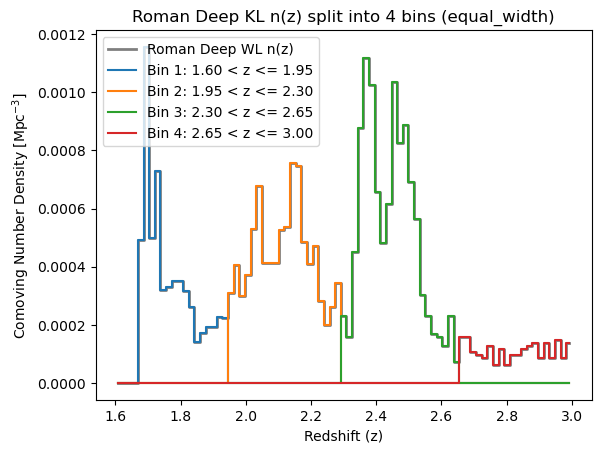

In [ ]:
# separate nz bins (updated 2026-02-24): Roman Deep n(z) with user-controlled bin count
num_density_bins = 81  # resolution of the n(z) curve
num_tomo_bins = 4      # user control: number of redshift bins
binning_mode = 'equal_width'  # 'equal_width' or 'equal_number'
z_min, z_max = 1.6, 3.0

z_deep = np.asarray(catalog_c25_photoz['zfinal'][roman_deep_KL])
valid = np.isfinite(z_deep) & (z_deep >= z_min) & (z_deep <= z_max)
z_deep = z_deep[valid]

# Area_C25 is in arcmin^2; convert to steradian
area_sr = (Area_C25 / 3600.0) * (np.pi / 180.0)**2

# High-resolution total n(z)
density_edges = np.linspace(z_min, z_max, num_density_bins + 1)
z_mid = 0.5 * (density_edges[:-1] + density_edges[1:])
dc_edges = Planck15.comoving_distance(density_edges).value  # Mpc
shell_vol = (area_sr / 3.0) * (dc_edges[1:]**3 - dc_edges[:-1]**3)  # Mpc^3
counts_total, _ = np.histogram(z_deep, bins=density_edges)
n_of_z_total = counts_total / shell_vol

# Tomographic bin edges controlled by num_tomo_bins
if binning_mode == 'equal_number':
    tomo_edges = np.quantile(z_deep, np.linspace(0.0, 1.0, num_tomo_bins + 1))
    tomo_edges[0], tomo_edges[-1] = z_min, z_max
else:
    tomo_edges = np.linspace(z_min, z_max, num_tomo_bins + 1)

plt.step(z_mid, n_of_z_total, where='mid', color='k', lw=2, alpha=0.5,
         label='Roman Deep WL n(z)')
for i in range(num_tomo_bins):
    lo, hi = tomo_edges[i], tomo_edges[i + 1]
    if i < num_tomo_bins - 1:
        in_bin = (z_mid >= lo) & (z_mid < hi)
    else:
        in_bin = (z_mid >= lo) & (z_mid <= hi)
    n_of_z_bin = np.where(in_bin, n_of_z_total, 0.0)
    plt.step(z_mid, n_of_z_bin, where='mid',
             label=f'Bin {i+1}: {lo:.2f} < z <= {hi:.2f}')
    #np.savez("./Roman_DeepKL_bin"+str(int(i+1))+".npz",z_mid,n_of_z_bin)
    #np.savez("./Roman_DeepKL.npz",z_mid,n_of_z_bin)

plt.xlabel('Redshift (z)')
plt.ylabel(r'Comoving Number Density [Mpc$^{-3}$]')
plt.title(f'Roman Deep KL n(z) split into {num_tomo_bins} bins ({binning_mode})')
plt.legend()
plt.show()


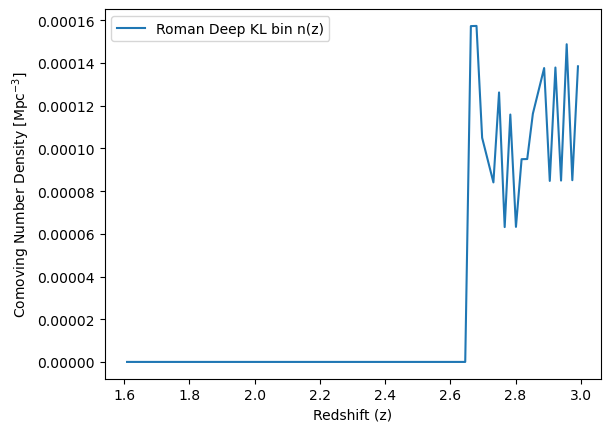

z_eff =  2.818887343407597
Average galaxy density nbar_bin Mpc^-3 = 0.00010895011555452051 Mpc3


In [70]:
# Roman Deep KL

z_bin1 = np.load("./Roman_DeepKL_bin4.npz")["arr_0"]   # z midpoints
nz_bin1 = np.load("./Roman_DeepKL_bin4.npz")["arr_1"]  # comoving number density [Mpc^-3]

plt.plot(z_bin1, nz_bin1, label="Roman Deep KL bin n(z)")
plt.xlabel("Redshift (z)")
plt.ylabel(r"Comoving Number Density [Mpc$^{-3}$]")
plt.legend()
plt.show()

area_arcmin2 = Area_C25
area_sr = (area_arcmin2 / 3600.0) * (np.pi / 180.0)**2

# n(z)^2-weighted effective redshift (你原来的量)
z_eff = np.trapezoid(z_bin1 * nz_bin1**2, z_bin1) / np.trapezoid(nz_bin1**2, z_bin1)
print("z_eff = ", z_eff)

mask = np.where( nz_bin1 > 0 )
chi_array = cosmo.comoving_distance(z_bin1[mask])
dchidz = np.gradient(chi_array,z_bin1[mask])
Vs = np.trapezoid( area_sr*chi_array**2*dchidz,z_bin1[mask] )
Vs = Vs.value
N_gal = np.trapezoid( nz_bin1[mask]*area_sr*chi_array**2*dchidz,z_bin1[mask] )
N_gal.value

# 平均星系密度
nbar_bin = N_gal / Vs

print("Average galaxy density nbar_bin Mpc^-3 =", nbar_bin)


In [74]:
### IA amplitude for Roman Deep Sample
red_blue_classification_Roman_Deep_KL = classify_red_blue_galaxies(
    catalog_c25_photoz[roman_deep_KL], 
    method='color', inclusive=2
    )
print(f'Red galaxy fraction in Roman Deep Sample: {red_blue_classification_Roman_Deep_KL["selection_stats"]["frac_red"]:.3f}')
print(f'Blue galaxy fraction in Roman Deep Sample: {red_blue_classification_Roman_Deep_KL["selection_stats"]["frac_blue"]:.3f}')


zmin = 2.65
zmax = 3.0

IA_amplitude_Roman_Deep_KL = estimate_IA_amplitude_withz(
    M_r=catalog_c25_photoz['mabs_r'][roman_deep_KL][red_blue_classification_Roman_Deep_KL['is_red']],
    redshift=catalog_c25_photoz['zfinal'][roman_deep_KL][red_blue_classification_Roman_Deep_KL['is_red']],
    z_min = zmin,
    z_max = zmax,
    model='johnston19',
    return_uncertainty=True
)

N_total = len( catalog_c25_photoz['mabs_r'][roman_deep_KL] )
N_bin = np.sum( (catalog_c25_photoz['zfinal'][roman_deep_KL] > zmin) 
                & (catalog_c25_photoz['zfinal'][roman_deep_KL] < zmax) )

print(f'Mean IA amplitude for the whole Roman Deep Sample: {IA_amplitude_Roman_Deep_KL[0].sum()/N_bin:.3f}')
print(f'Mean IA amplitude for the red Roman Deep Sample bin: {IA_amplitude_Roman_Deep_KL[0].sum()/len(IA_amplitude_Roman_Deep_KL[0]):.3f}')

Red galaxy fraction in Roman Deep Sample: 0.025
Blue galaxy fraction in Roman Deep Sample: 0.870
Mean IA amplitude for the whole Roman Deep Sample: 0.000
Mean IA amplitude for the red Roman Deep Sample bin: nan


C:\Users\11020\AppData\Local\Temp\ipykernel_33348\1175563573.py:27: RuntimeWarning: invalid value encountered in scalar divide
  print(f'Mean IA amplitude for the red Roman Deep Sample bin: {IA_amplitude_Roman_Deep_KL[0].sum()/len(IA_amplitude_Roman_Deep_KL[0]):.3f}')


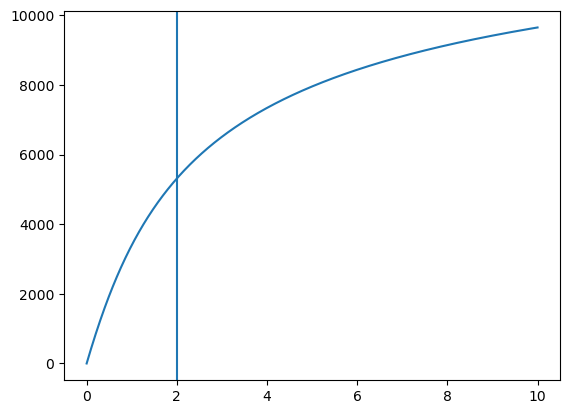

In [22]:
z_array = np.linspace(0,10,1000)
chi = Planck15.comoving_distance(z_array)
### Interpolate the relation


plt.plot(z_array, chi)

plt.axvline(2)

In [2]:
# derive b2 from b1
def b1b2(b1):
    return 0.412 - 2.143*b1+0.929*b1**2+0.008*b1**3

Fitted function: b1 = 0.87 * z + 1.46


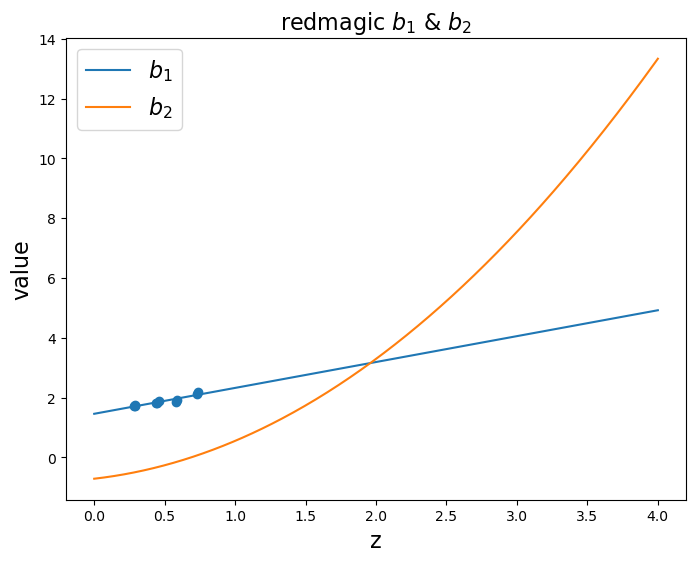

In [3]:
# redmagic b1
# Linear fit based on z_array and b1

z_raw = np.array([0.279, 0.288, 0.290, 0.439, 0.447, 0.457, 0.579, 0.588, 0.727, 0.738])
b1_raw = np.array([1.729, 1.711, 1.746, 1.828, 1.811, 1.881, 1.859, 1.933, 2.115, 2.173])

k, b = np.polyfit(z_raw, b1_raw, 1)
print(f'Fitted function: b1 = {k:.2f} * z + {b:.2f}')
z_new = np.linspace(0,4,400)

fig = plt.figure(figsize=(8,6))
plt.title(r"redmagic $b_1$ & $b_2$",fontsize=16)
plt.scatter(z_raw,b1_raw)
plt.plot(z_new,k*z_new+b,label=r"$b_{1}$")
plt.plot(z_new,b1b2(k*z_new+b),label=r"$b_{2}$")
plt.xlabel("z",fontsize=16)
plt.ylabel("value",fontsize=16)
plt.legend(fontsize=16)
plt.show()


Fitted function: b1 = 0.87 * z + 0.47


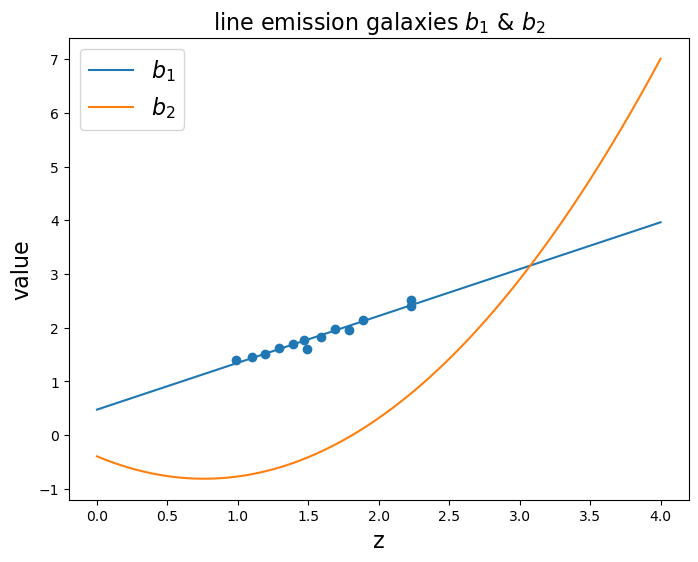

In [4]:
# line emission galaxies b1
z_raw = np.array([0.99, 1.10, 1.19, 1.29, 1.39, 1.49, 1.47, 1.59, 1.69, 1.79, 1.89, 2.23, 2.23])
b1_raw = np.array([1.40, 1.46, 1.51, 1.63, 1.70, 1.61, 1.78, 1.82, 1.97, 1.96, 2.15, 2.40, 2.52])

k, b = np.polyfit(z_raw, b1_raw, 1)
print(f'Fitted function: b1 = {k:.2f} * z + {b:.2f}')
z_new = np.linspace(0,4,400)

fig = plt.figure(figsize=(8,6))
plt.title(r"line emission galaxies $b_1$ & $b_2$",fontsize=16)
plt.scatter(z_raw,b1_raw)
plt.plot(z_new,k*z_new+b,label=r"$b_{1}$")
plt.plot(z_new,b1b2(k*z_new+b),label=r"$b_{2}$")
plt.xlabel("z",fontsize=16)
plt.ylabel("value",fontsize=16)
plt.legend(fontsize=16)
plt.show()

In [85]:
0.87*1.18+1.46,b1b2(2.49)

(2.4866, 0.959328892000001)